# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split

In [2]:
file_path = "../Database/spotify_songs_initial_cleaned.xlsx"
df = pd.read_excel(file_path)

# Train-Test Split

In [3]:
target_column = "track_popularity"

X = df.drop(columns = [target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f"X_train shape = {X_train.shape}")
print(f"X_test shape = {X_test.shape}")

X_train shape = (26243, 23)
X_test shape = (6561, 23)


# Data Senity Check (data initial visibility)

In [4]:
continuous_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 
    'valence', 'tempo', 'duration_sec', 'track_age'
]

In [5]:
print("Descriptive Statistics for Continuous Features (Train Set):")
display(X_train[continuous_features].describe())

Descriptive Statistics for Continuous Features (Train Set):


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_sec,track_age
count,26243.000000,26243.000000,26243.000000,26243.000000,26243.000000,26243.000000,26243.000000,26243.000000,26243.000000,26243.000000,26243.000000
mean,0.654552,0.698074,-6.724144,0.106921,0.175881,0.084676,0.190569,0.509691,120.879642,225.677226,14.813855
std,0.144727,0.181283,2.997816,0.101515,0.220058,0.224129,0.154953,0.233255,26.885870,59.707498,11.385014
min,0.000000,0.008140,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,6.000000
25%,0.562000,0.580000,-8.196500,0.040800,0.015200,0.000000,0.092800,0.330000,99.963500,187.840000,7.000000
50%,0.671000,0.721000,-6.164000,0.062200,0.081100,0.000016,0.127000,0.511000,121.977000,215.973000,10.000000
75%,0.760000,0.840000,-4.641000,0.131000,0.255000,0.004850,0.249500,0.693000,133.661000,253.129000,18.000000
max,0.983000,1.000000,1.275000,0.918000,0.994000,0.994000,0.992000,0.991000,239.440000,517.810000,69.000000


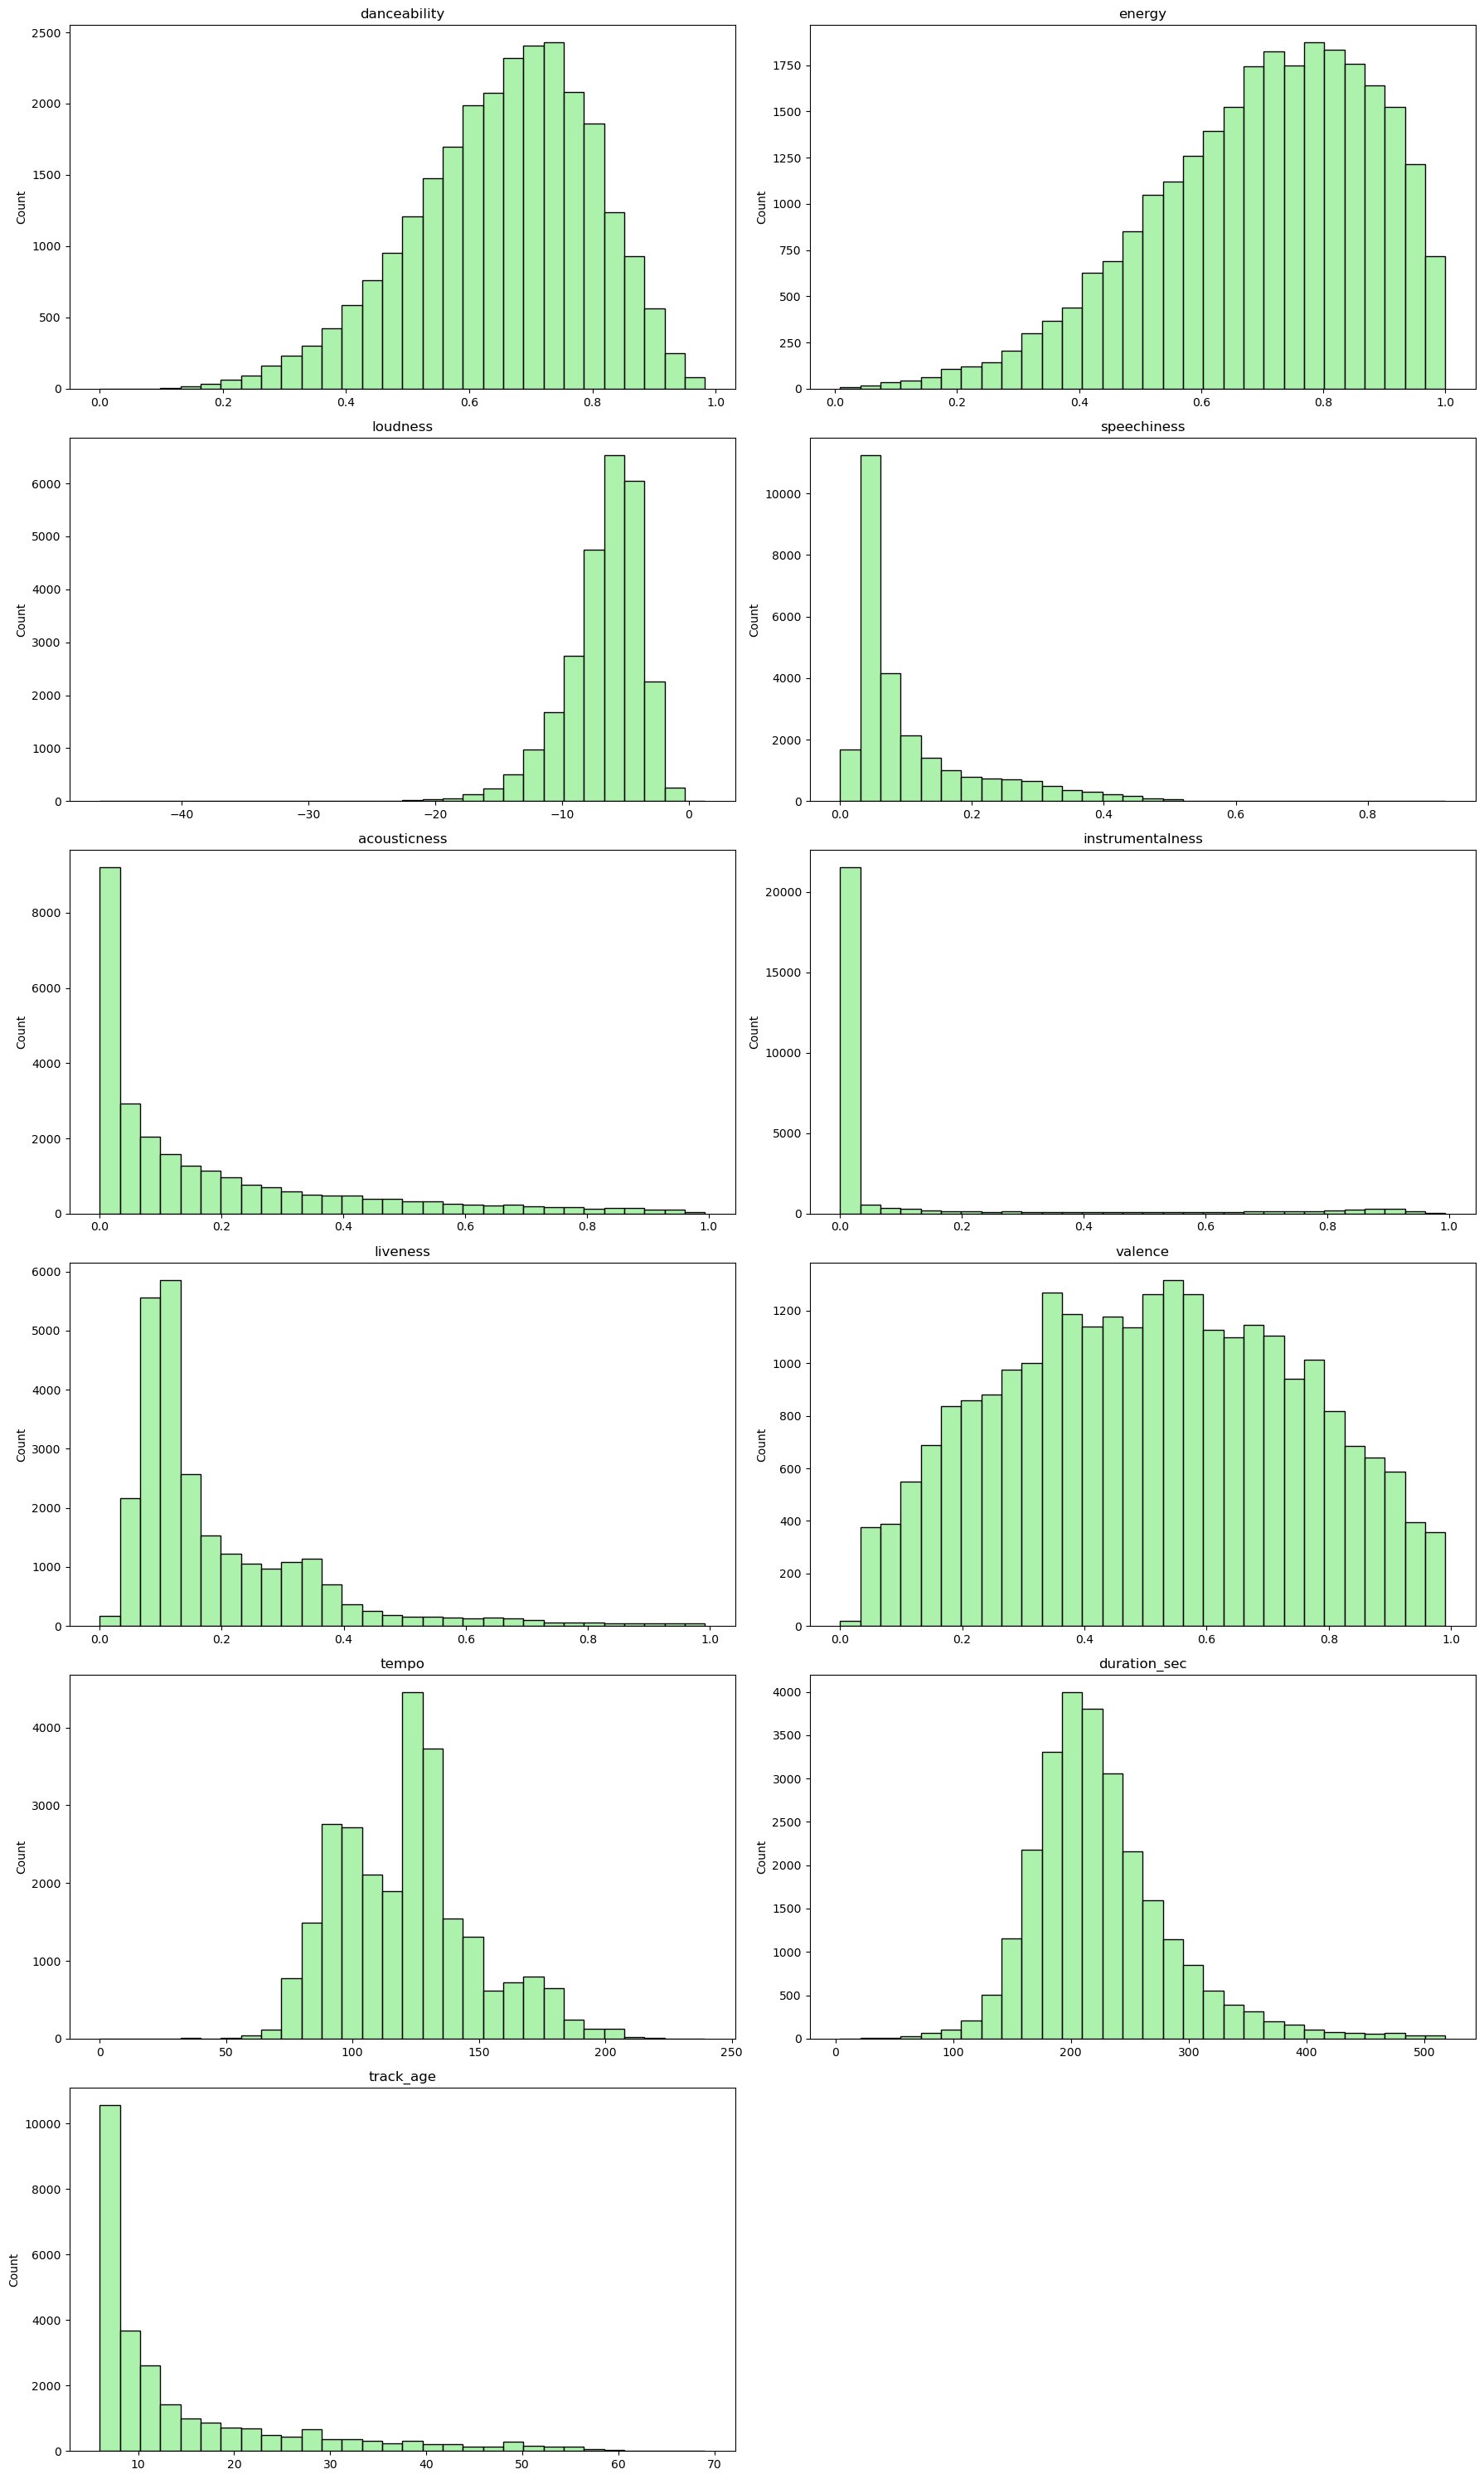

In [6]:
plt.figure(figsize = (18,30))
for i, col in enumerate(continuous_features, 1):
    plt.subplot(6,2,i)
    sns.histplot(x = X_train[col], bins = 30, color = 'lightgreen')
    plt.title(f"{col}")
    plt.xlabel("")

plt.tight_layout()
plt.show()

# Features Tranformations

In [7]:
def transformations_QQ_plots(feature, transforms, titles):
    fig, axes = plt.subplots(2,3, figsize = (18,10))
    fig.suptitle(f'Transformations QQ-Plots: {feature}', fontsize=18, y=1.02)
    axes = axes.flatten()

    for i, trans_title in enumerate(titles):
        stats.probplot(transforms[i], dist = "norm", plot = axes[i])
        axes[i].set_title(titles[i])
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
    
    plt.tight_layout()
    plt.show()

In [8]:
def plot_transformations(data, feature):
    
    x = data[feature].dropna()
    x_shifted = x + abs(x.min() + 0.001) if x.min() >= 0 else x

    trans_log = np.log(x_shifted)
    trans_sqrt = np.sqrt(x_shifted)
    trans_recip = 1 / x_shifted
    trans_exp = (x_shifted) ** 2
    trans_yj = stats.yeojohnson(x)[0]

    titles = ['Original', 'Log Transform','Sqrt Transform', 'Reciprocal Transform', 'Exponential Transform', 'YJ Transform']  
    transforms = [x, trans_log, trans_sqrt, trans_recip, trans_exp, trans_yj]  
    colors = ['gray', 'blue', 'green', 'orange', 'red', 'purple']

    fig, axes = plt.subplots(2,3, figsize = (18,10))
    fig.suptitle(f'Comprehensive Transformation Analysis: {feature}', fontsize=18, y=1.02)
    axes = axes.flatten()

    for i, trans_title in enumerate(titles):
        sns.histplot(transforms[i], bins = 30, kde = True, ax = axes[i], color = colors[i])
        axes[i].set_title(f"{trans_title}, (skewness: {pd.Series(transforms[i]).skew(): .2f})")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")

    plt.tight_layout()
    plt.show()

    transformations_QQ_plots(feature, transforms, titles)


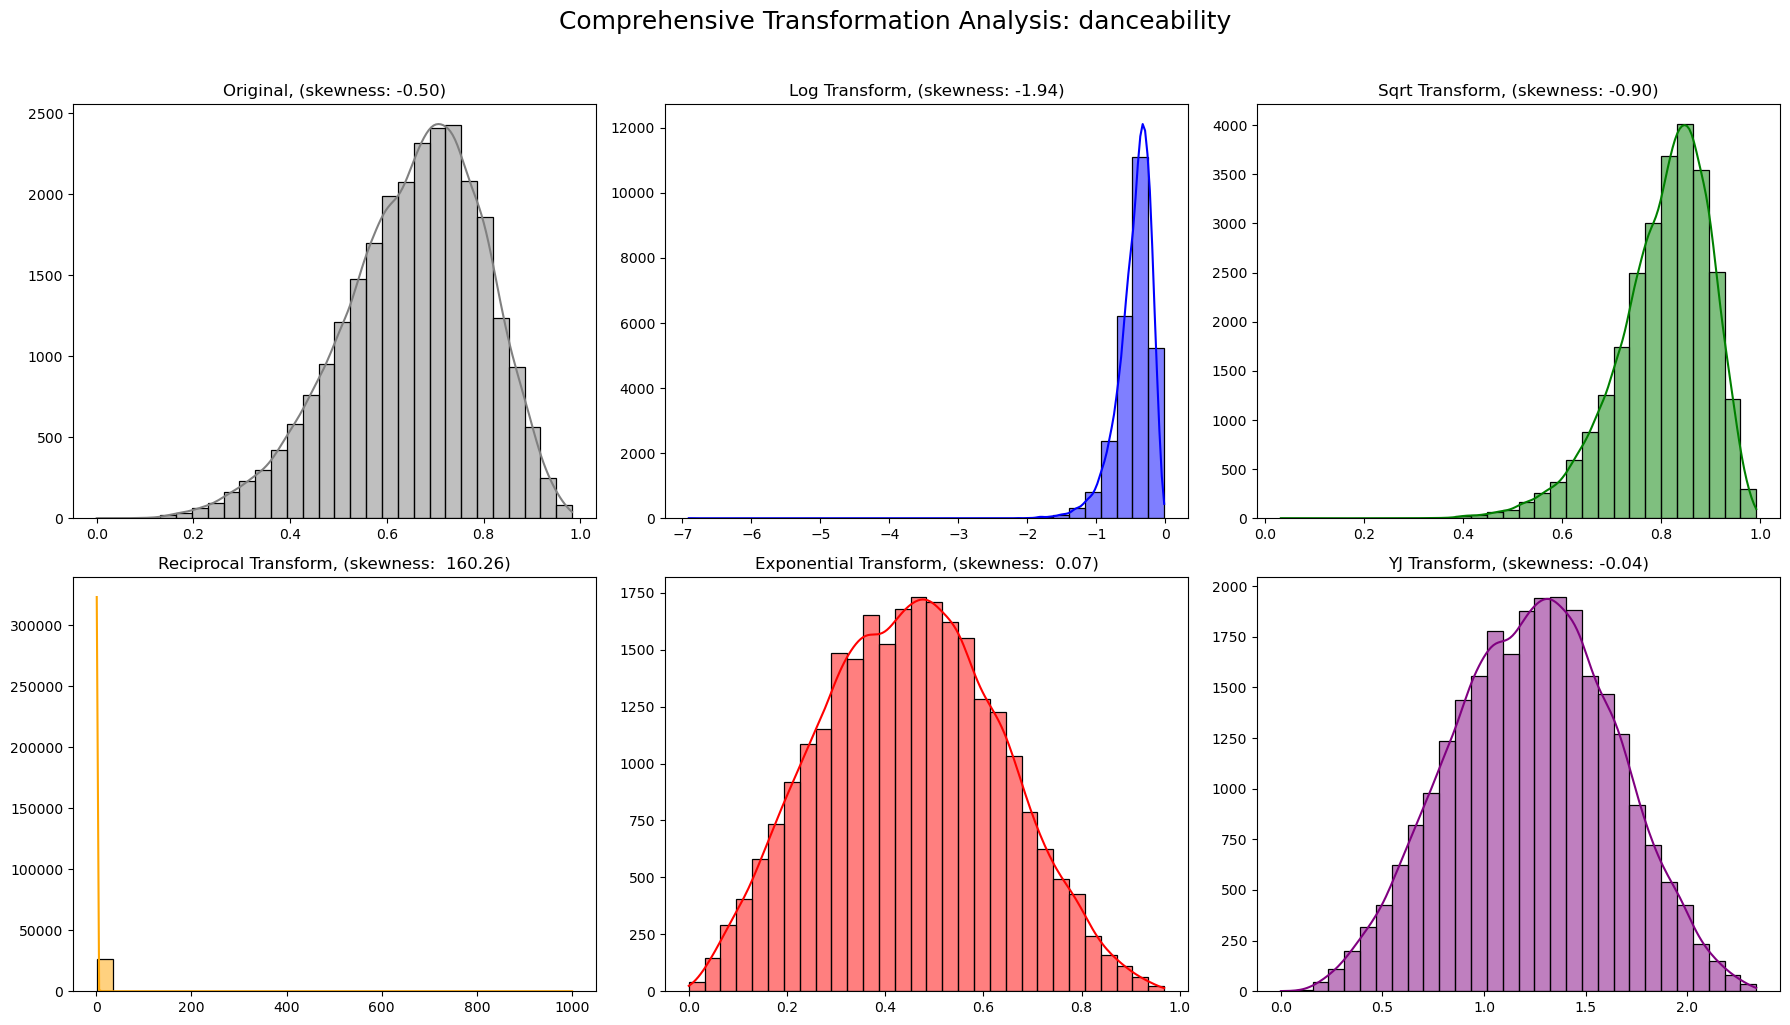

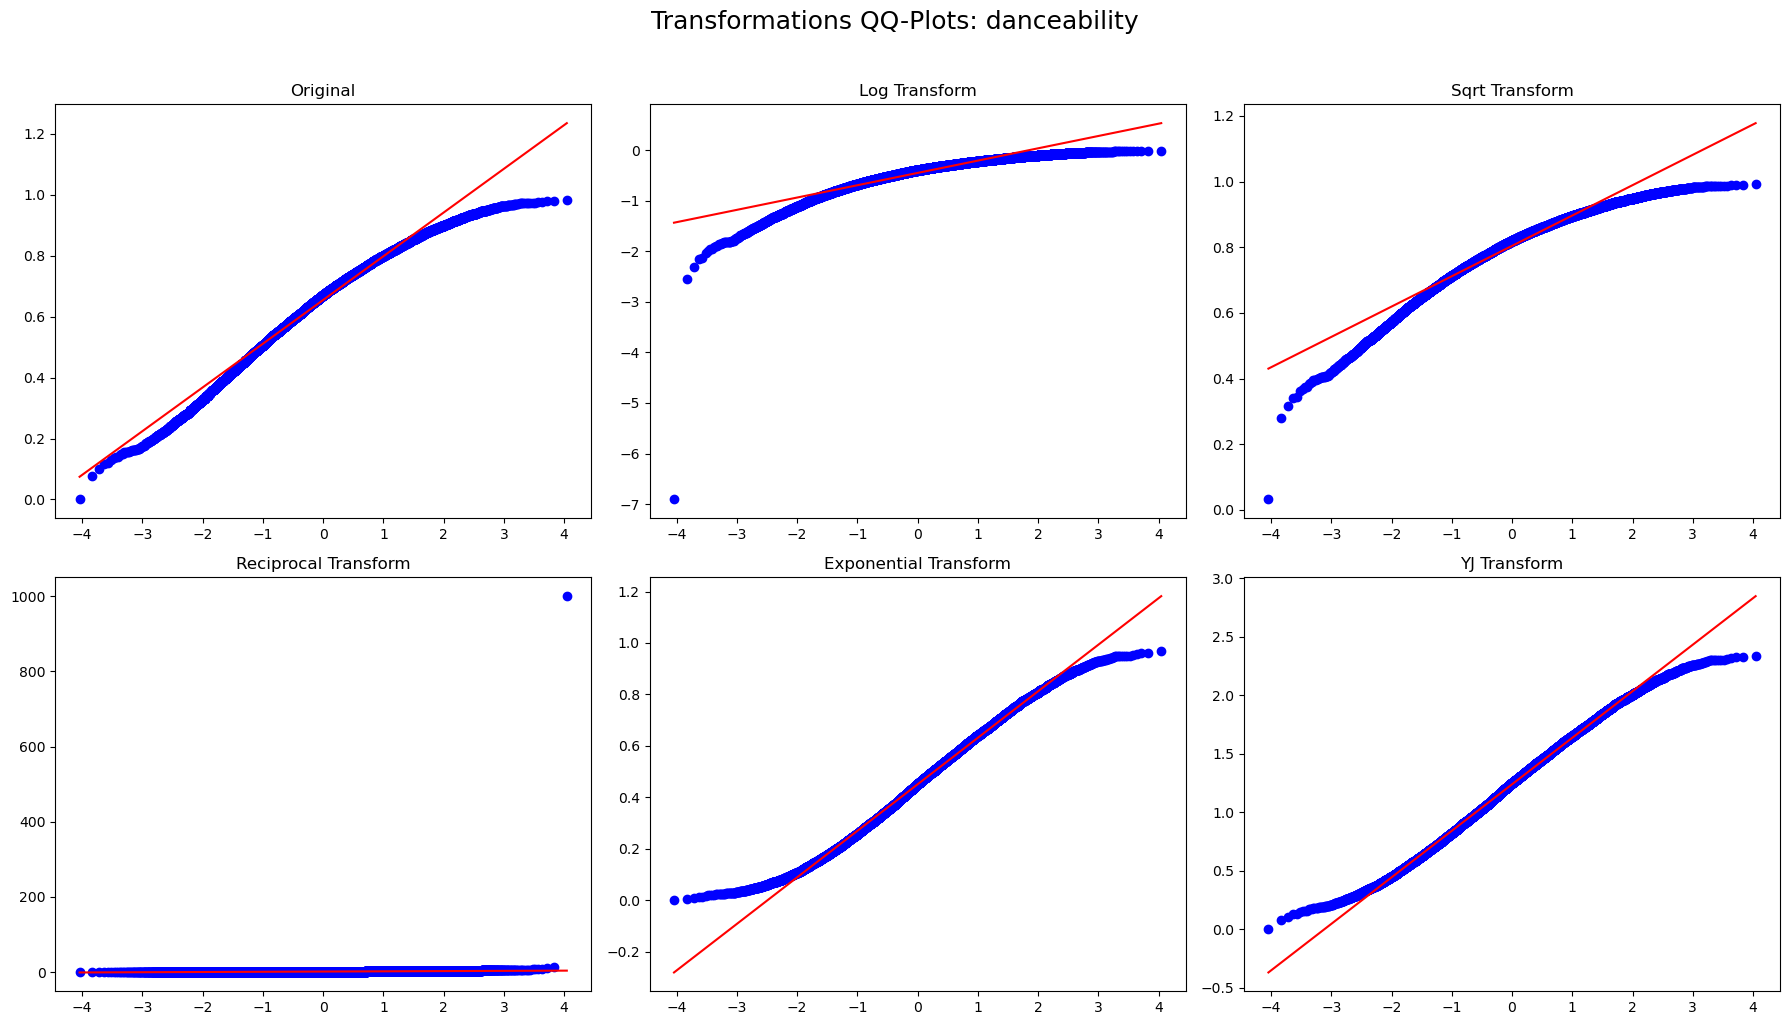

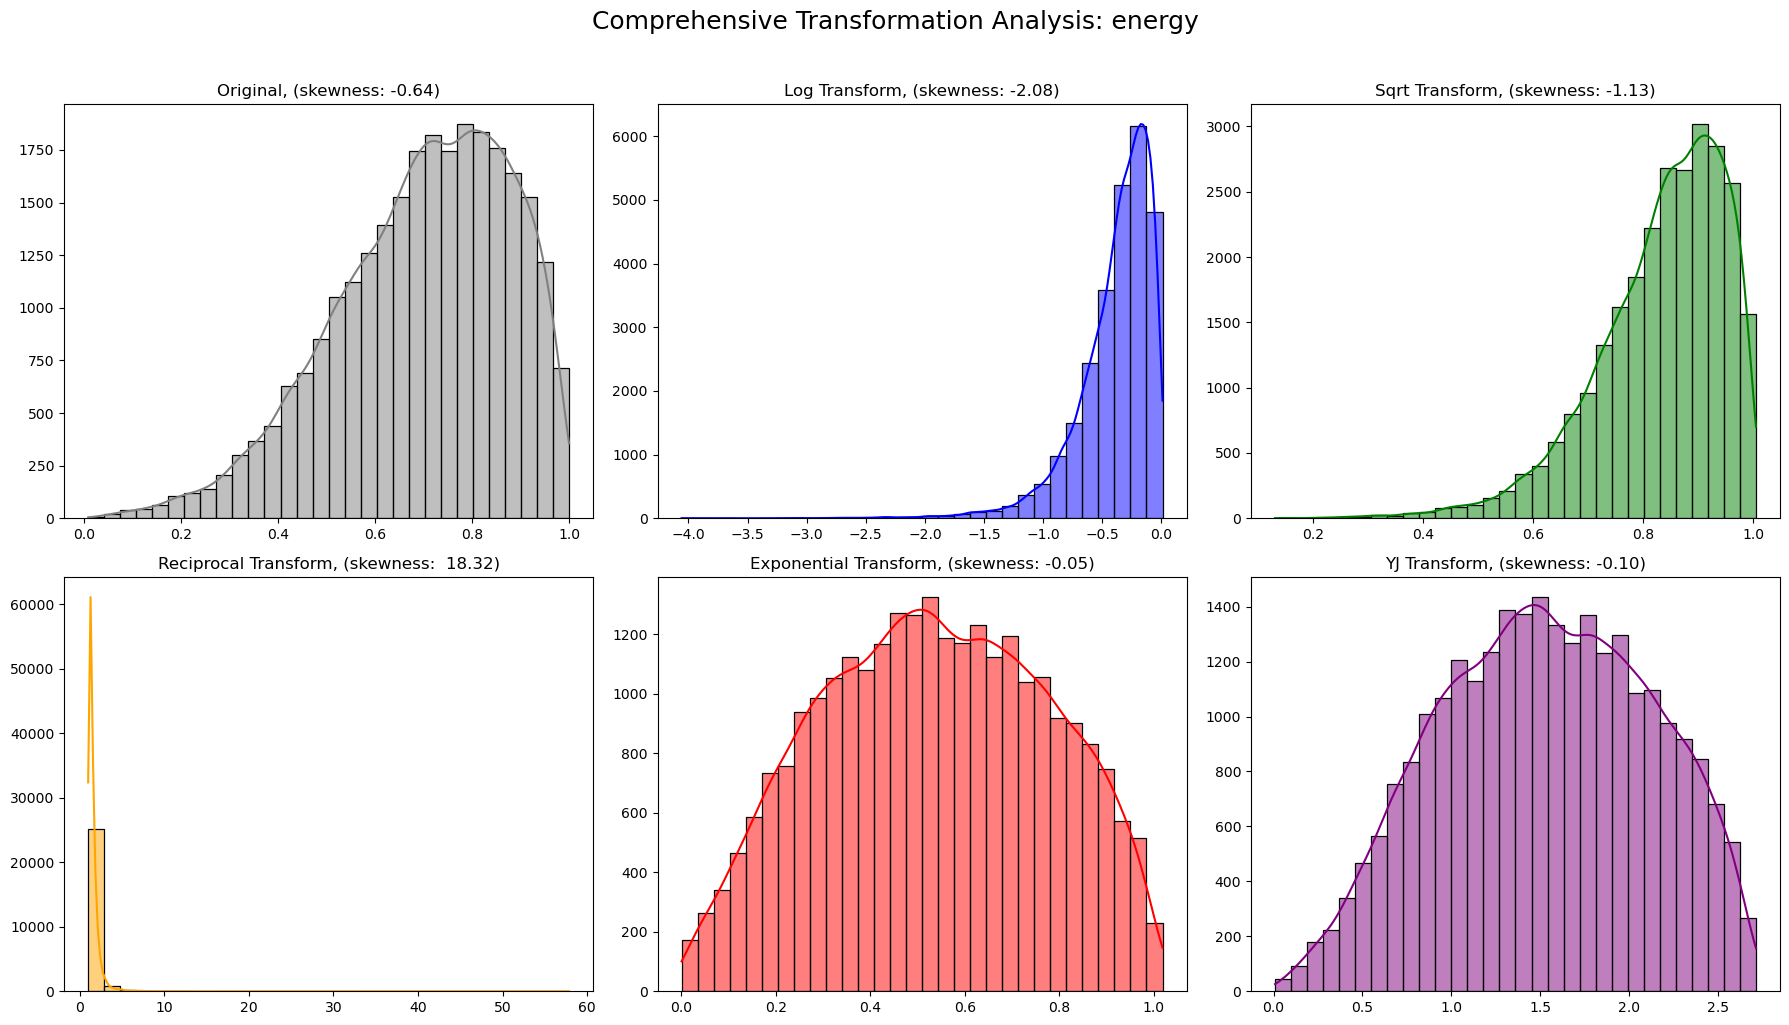

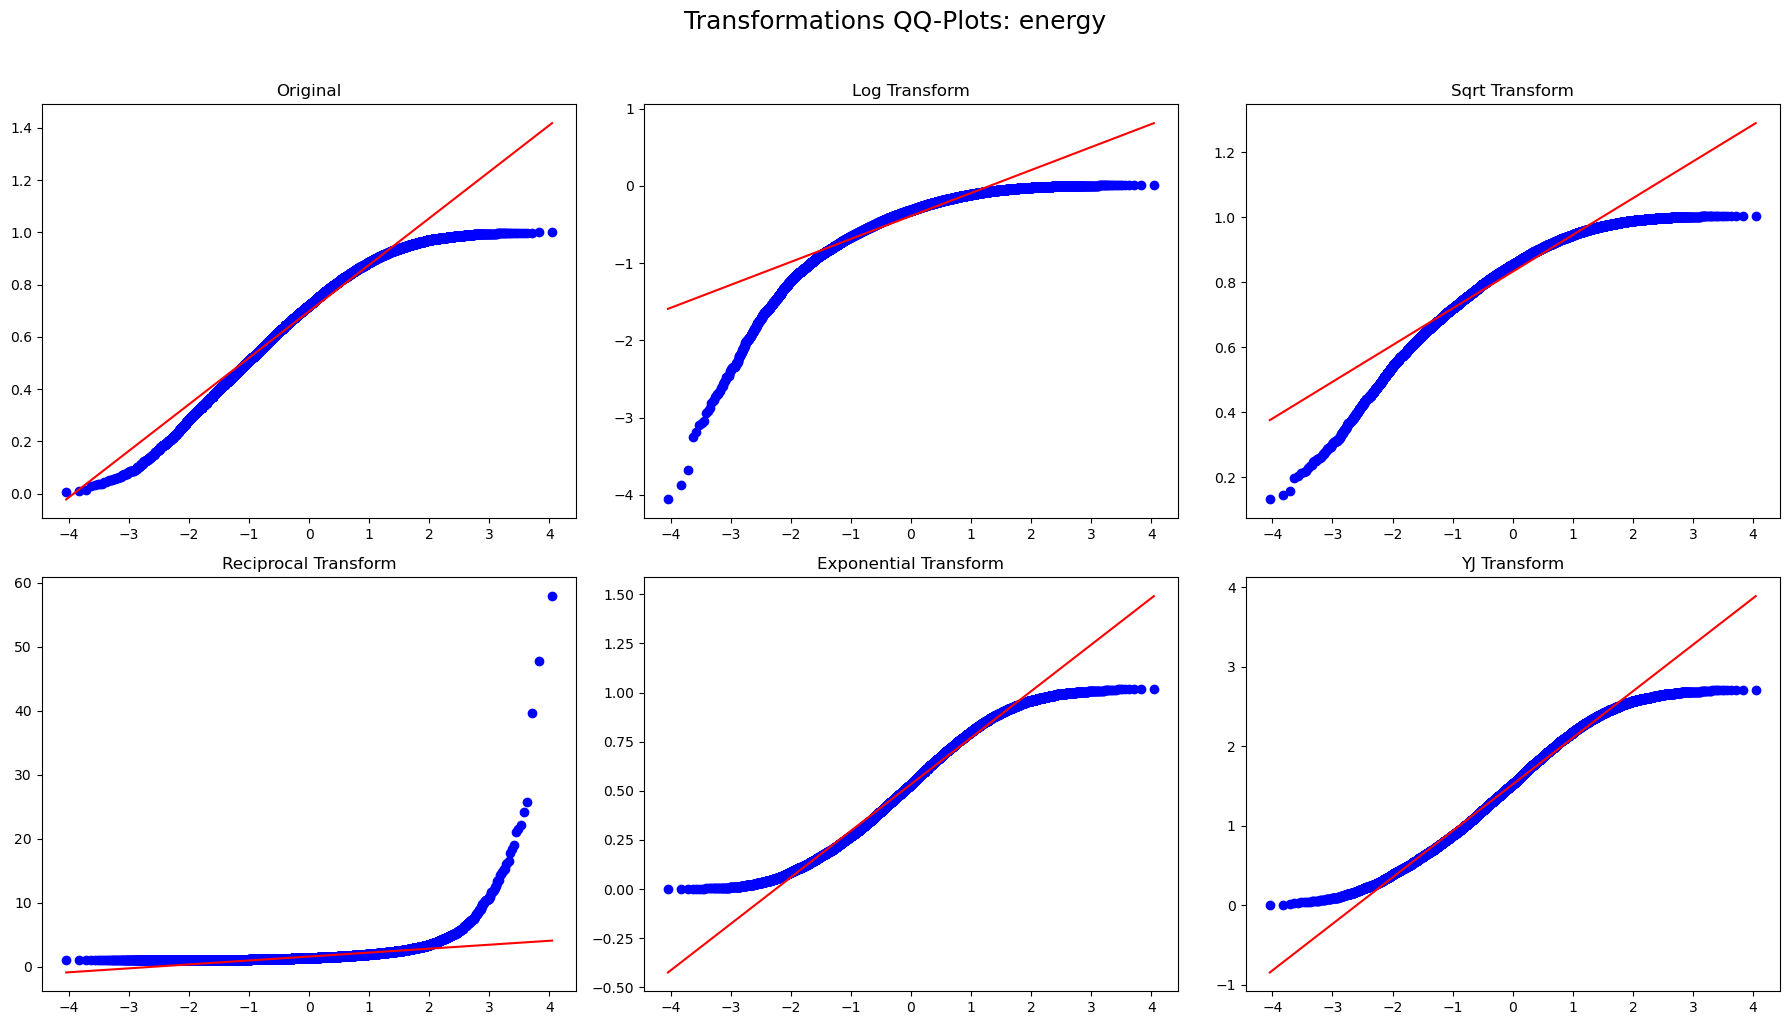

c:\Users\user\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


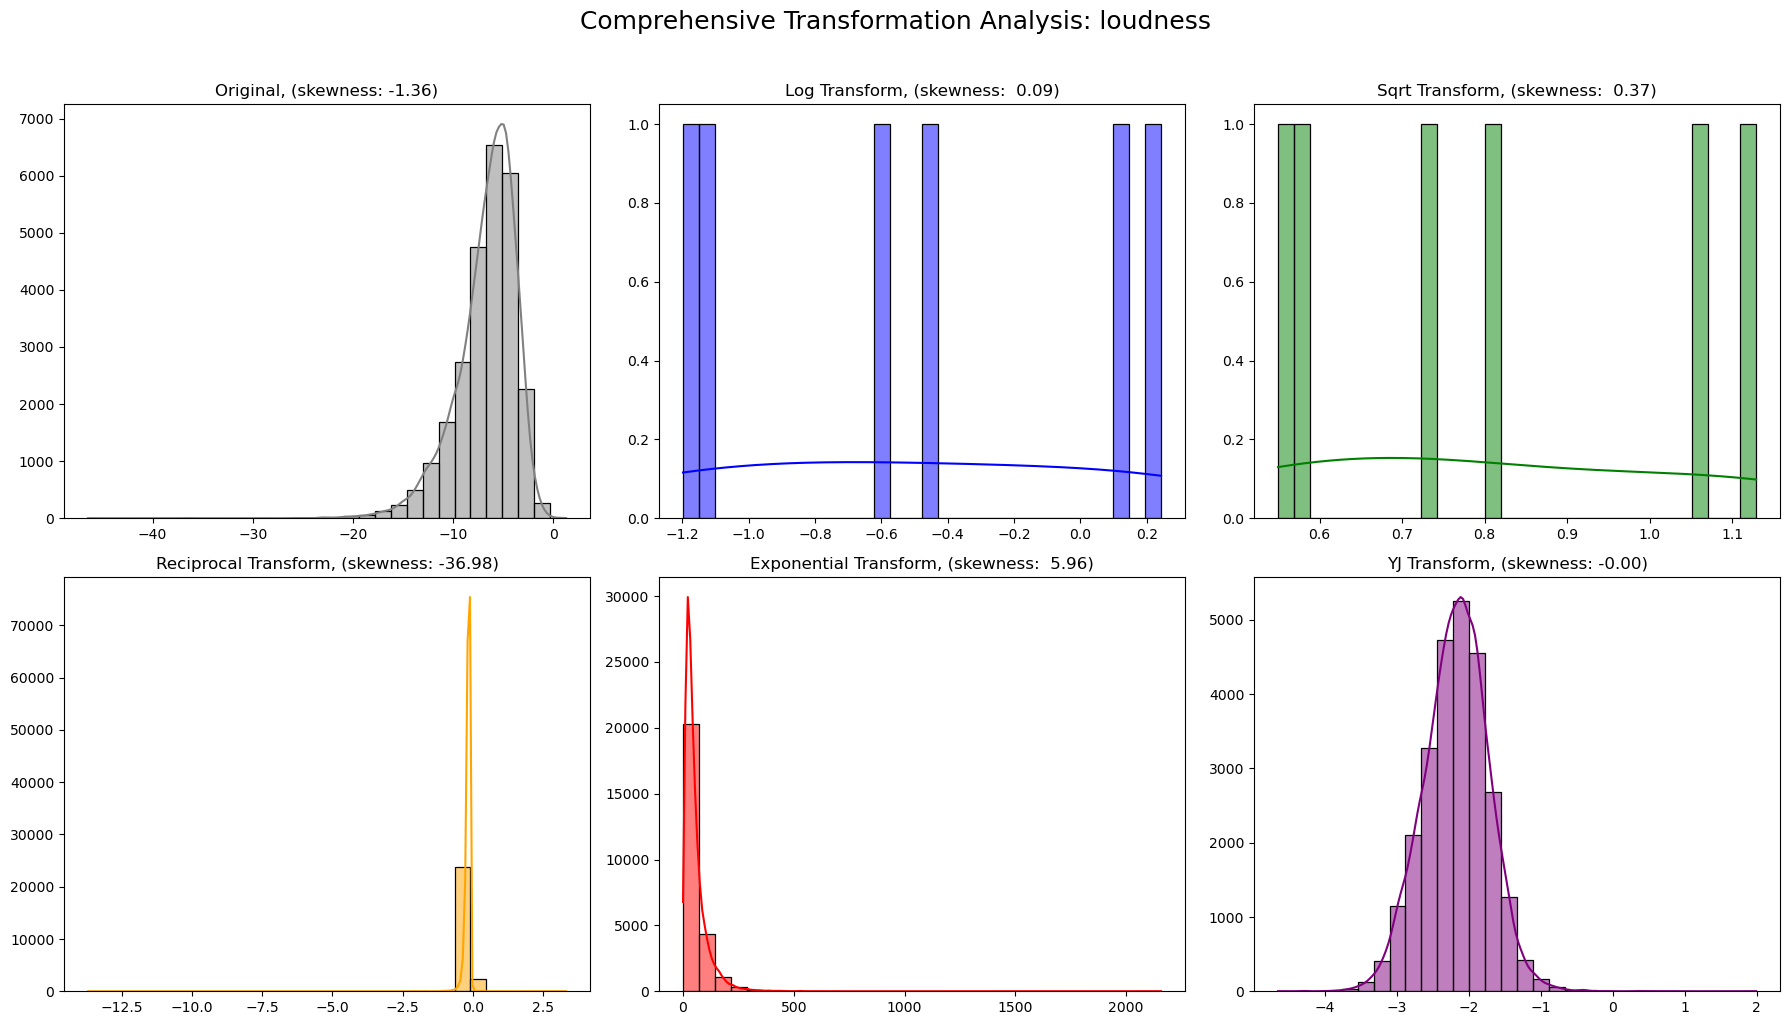

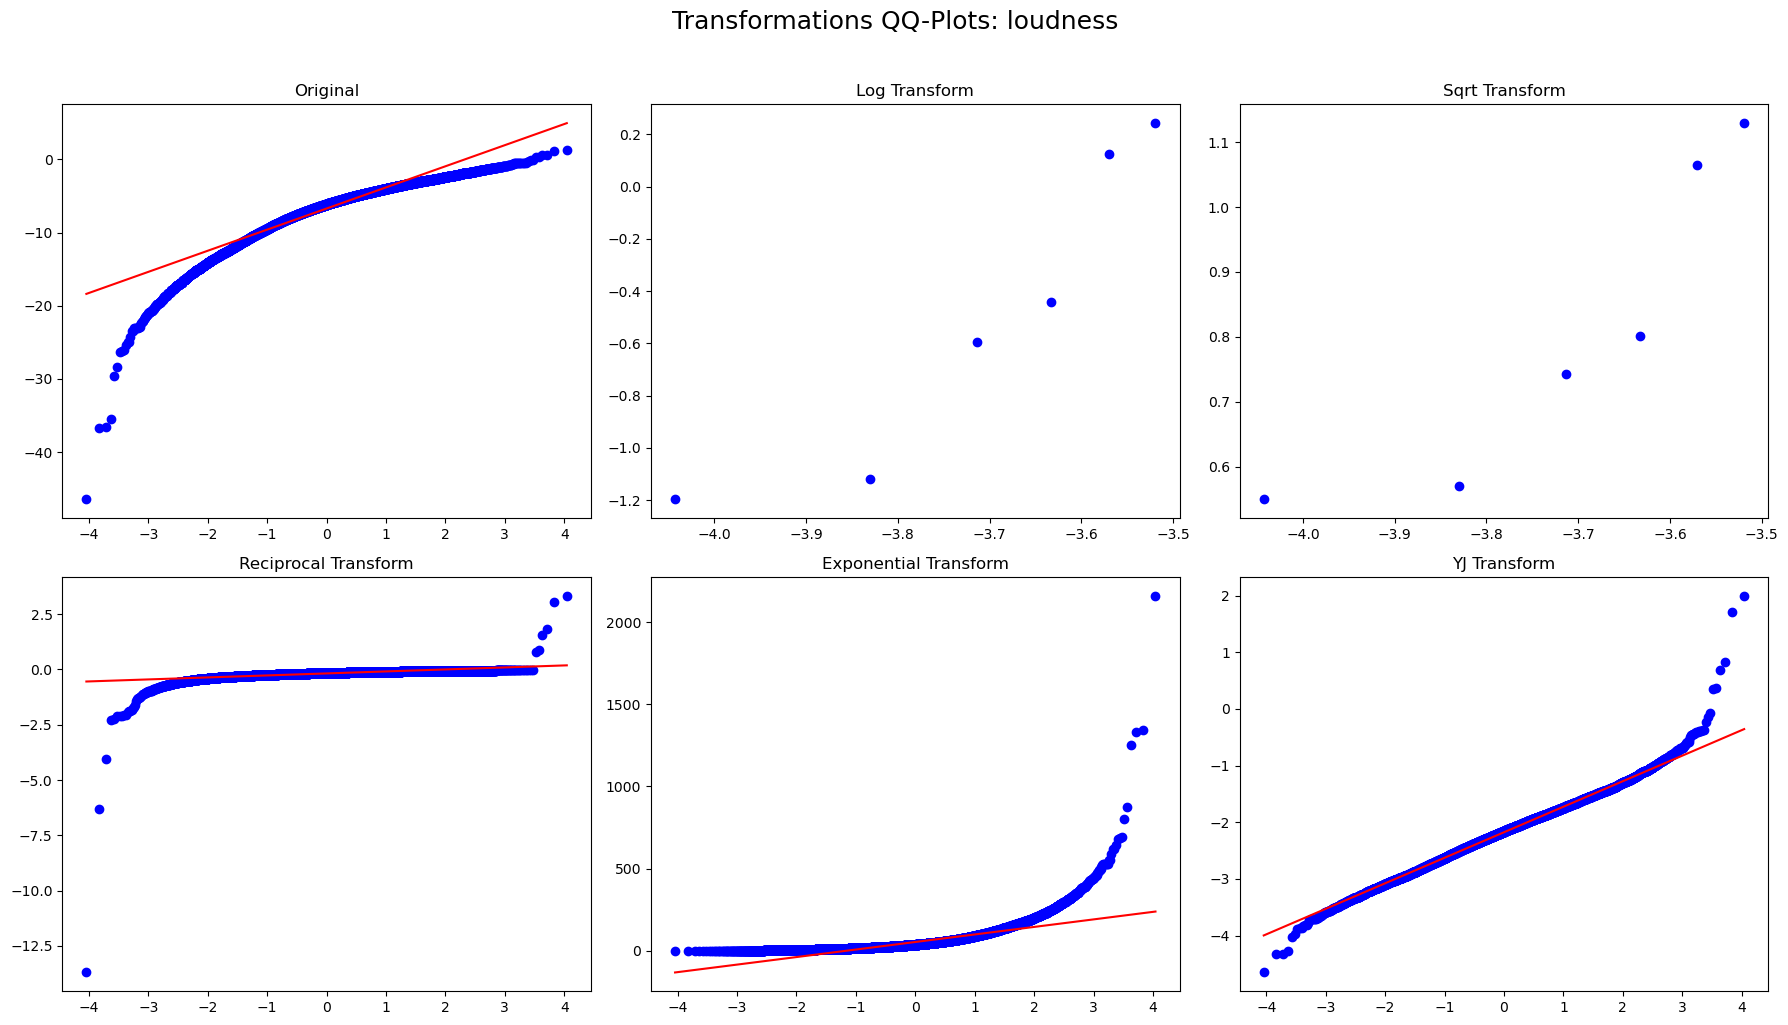

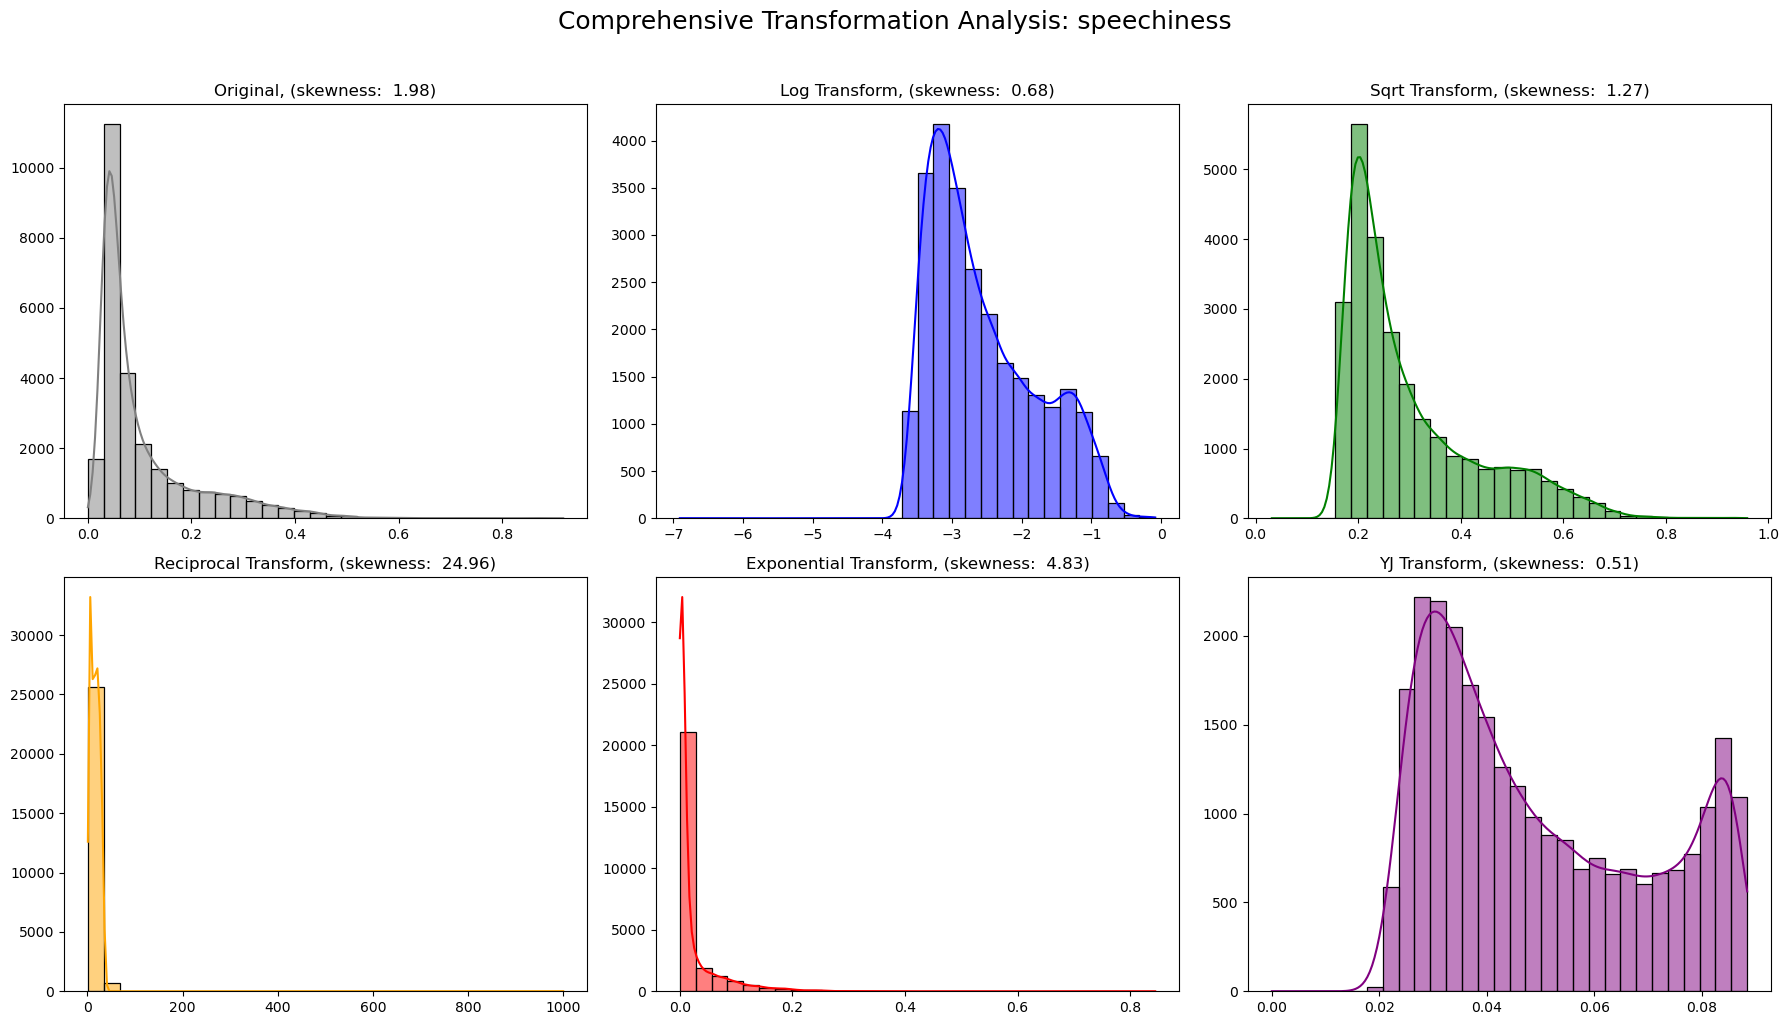

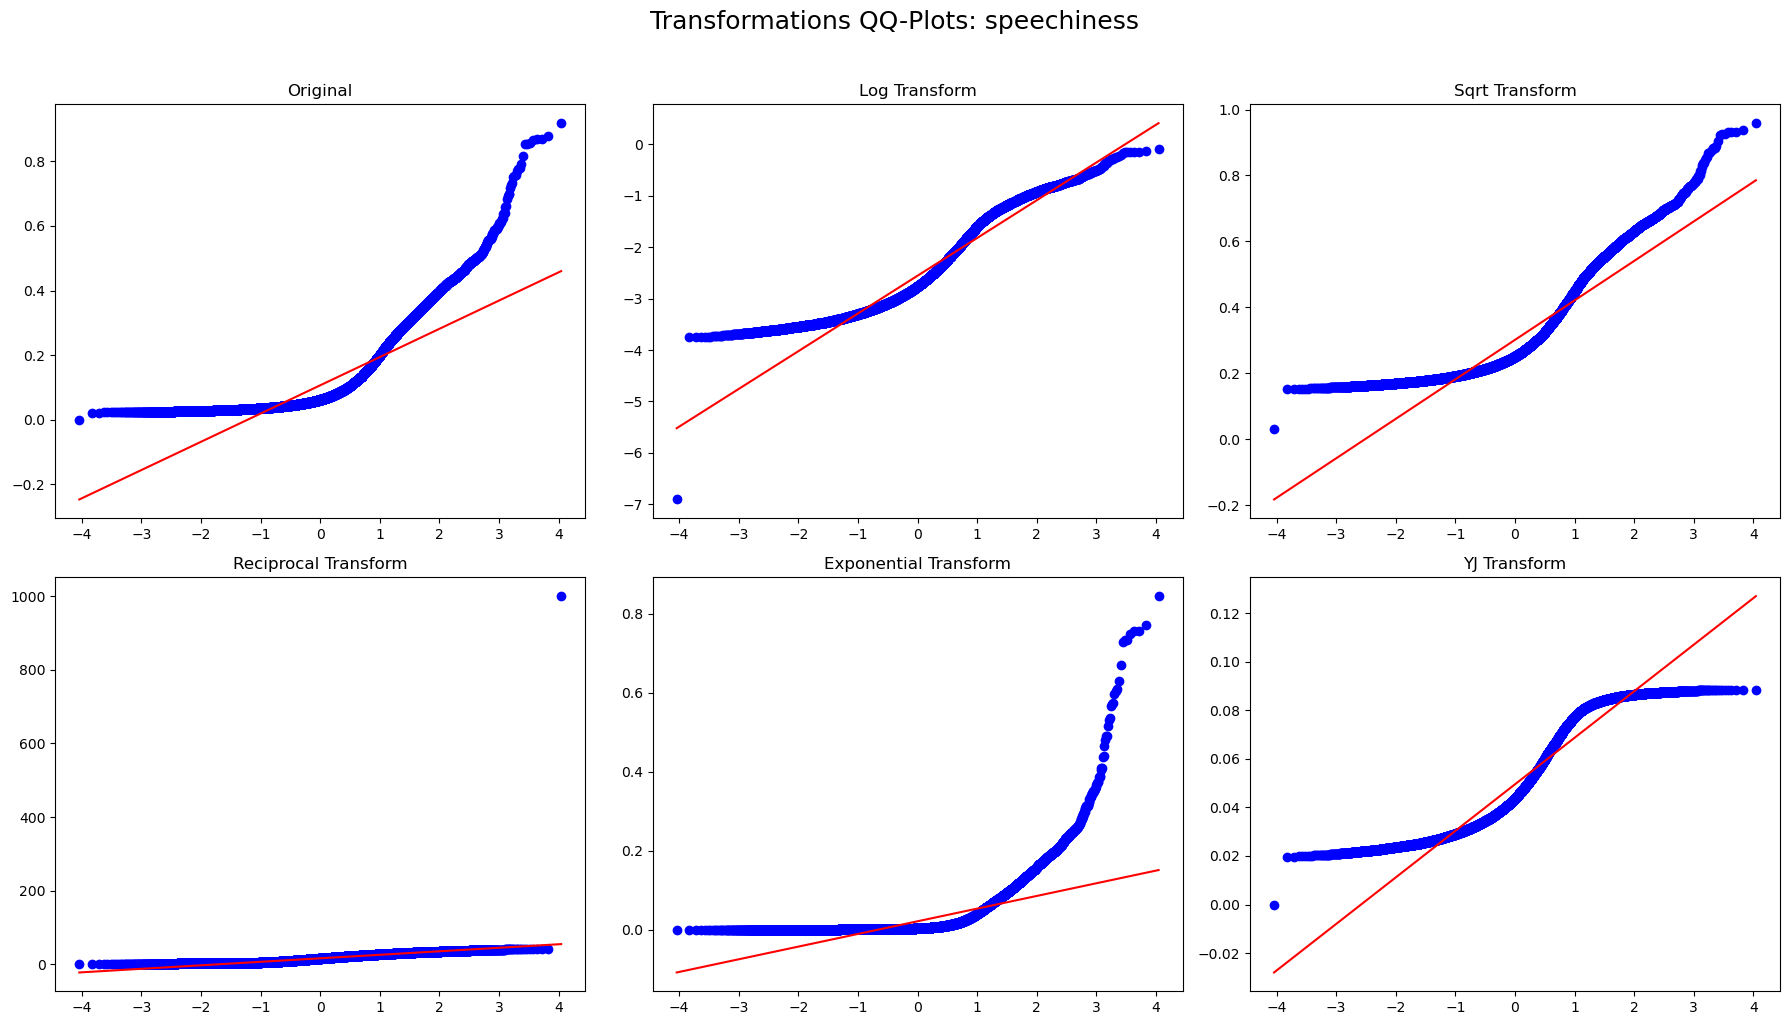

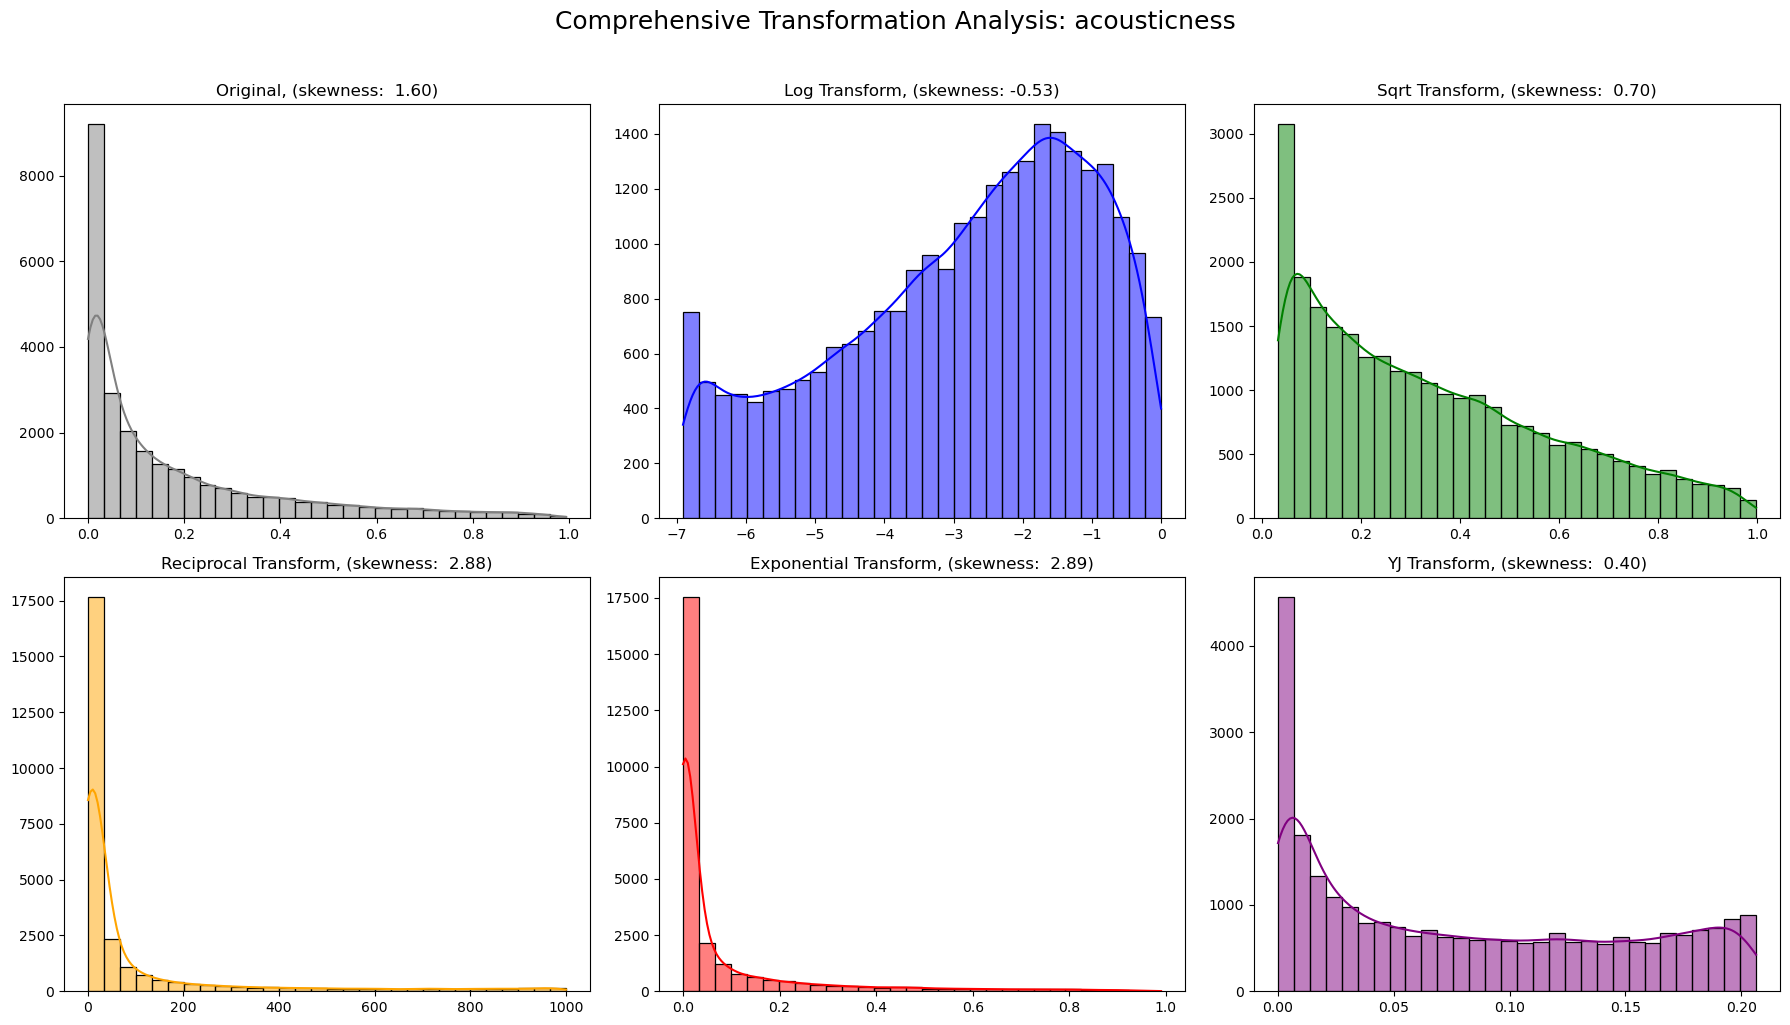

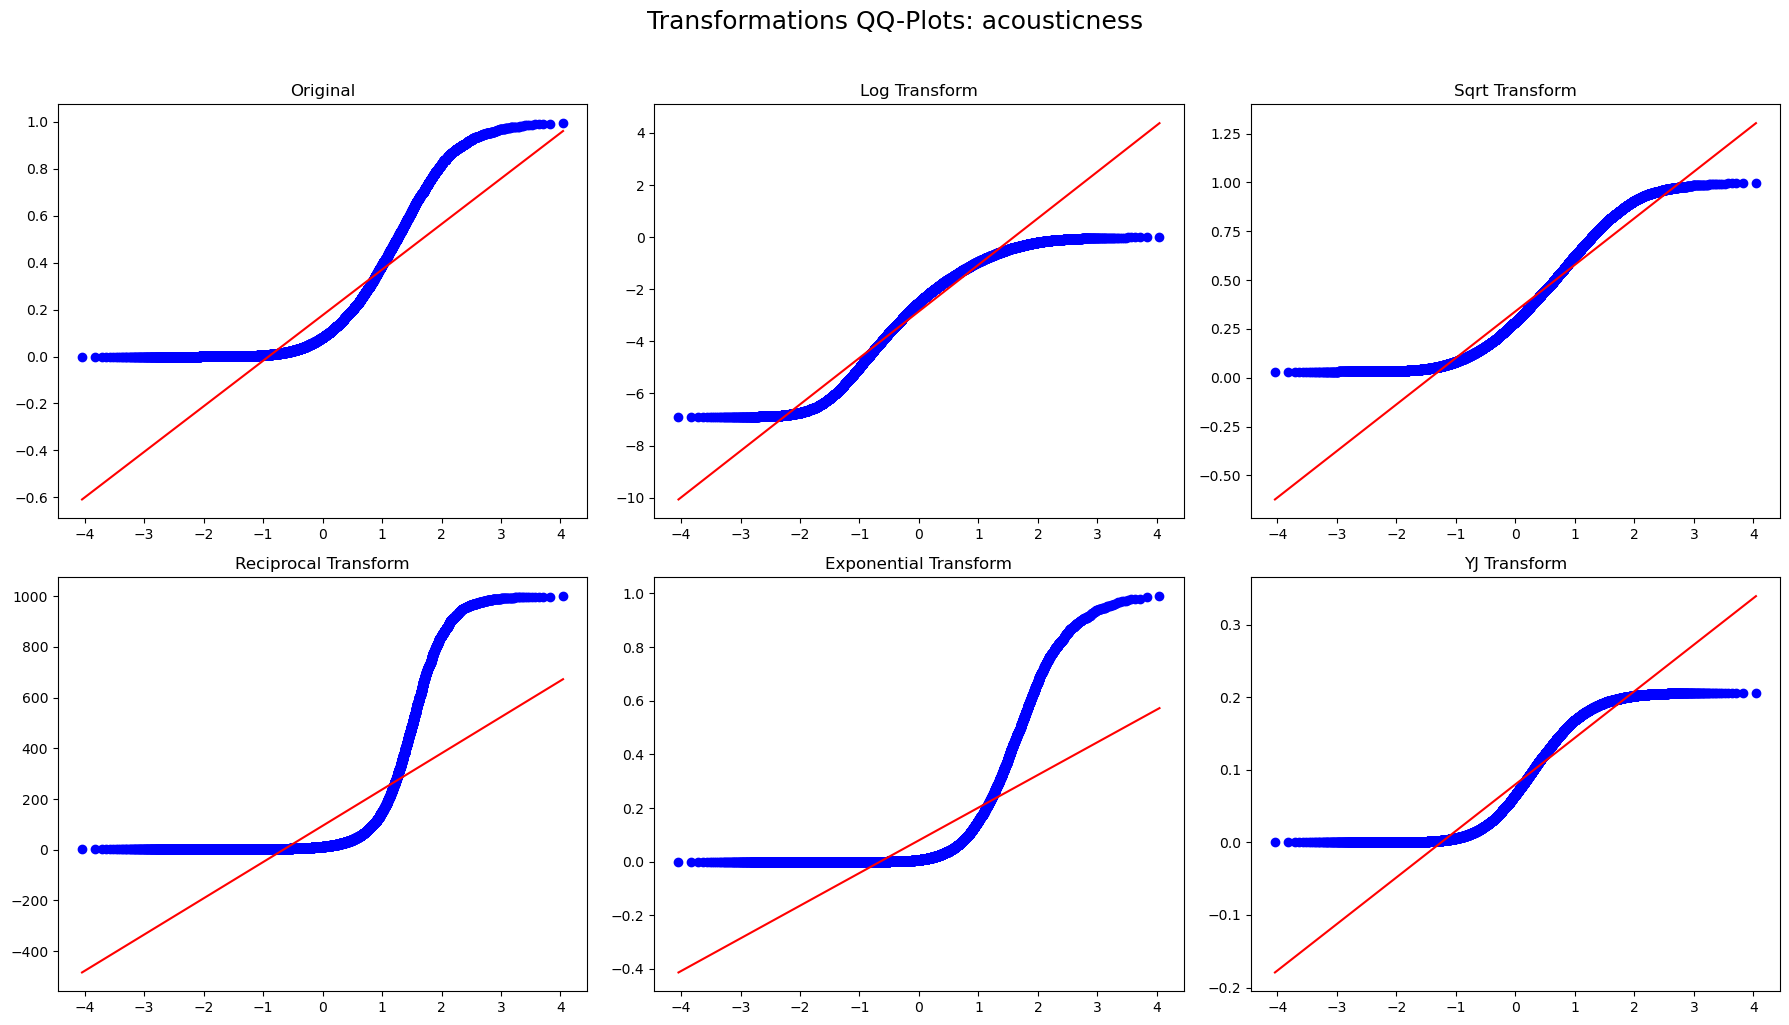

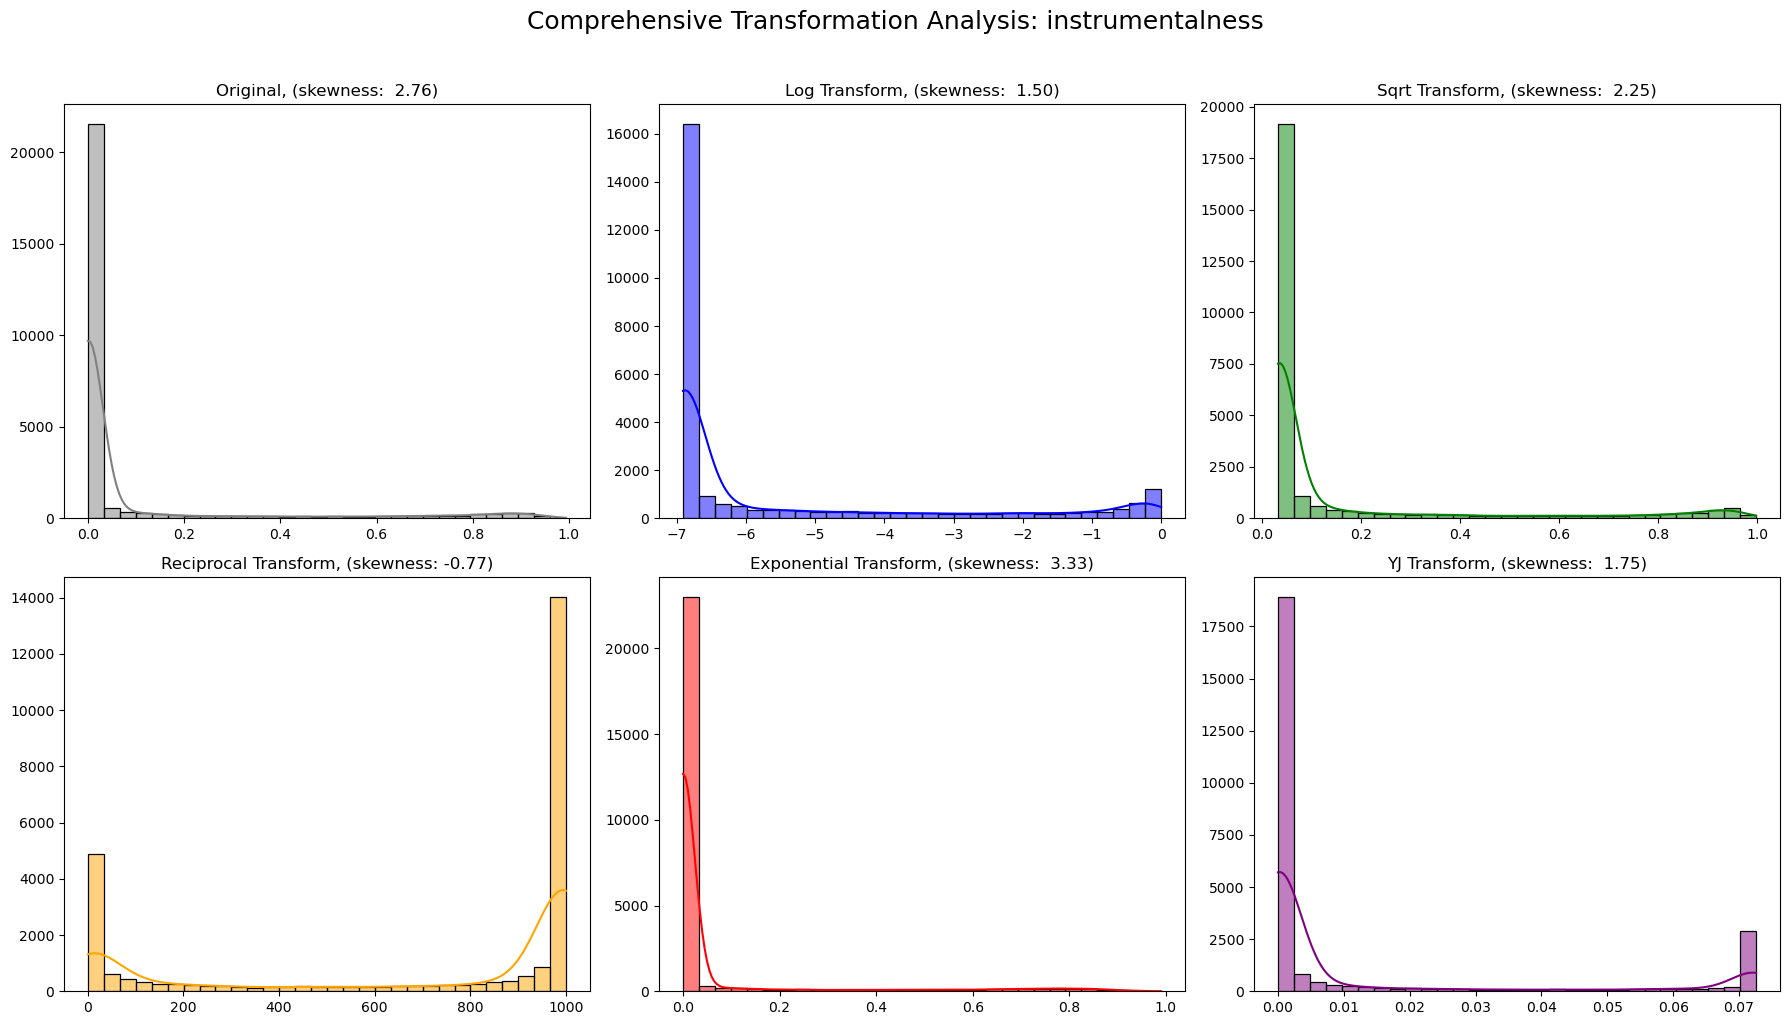

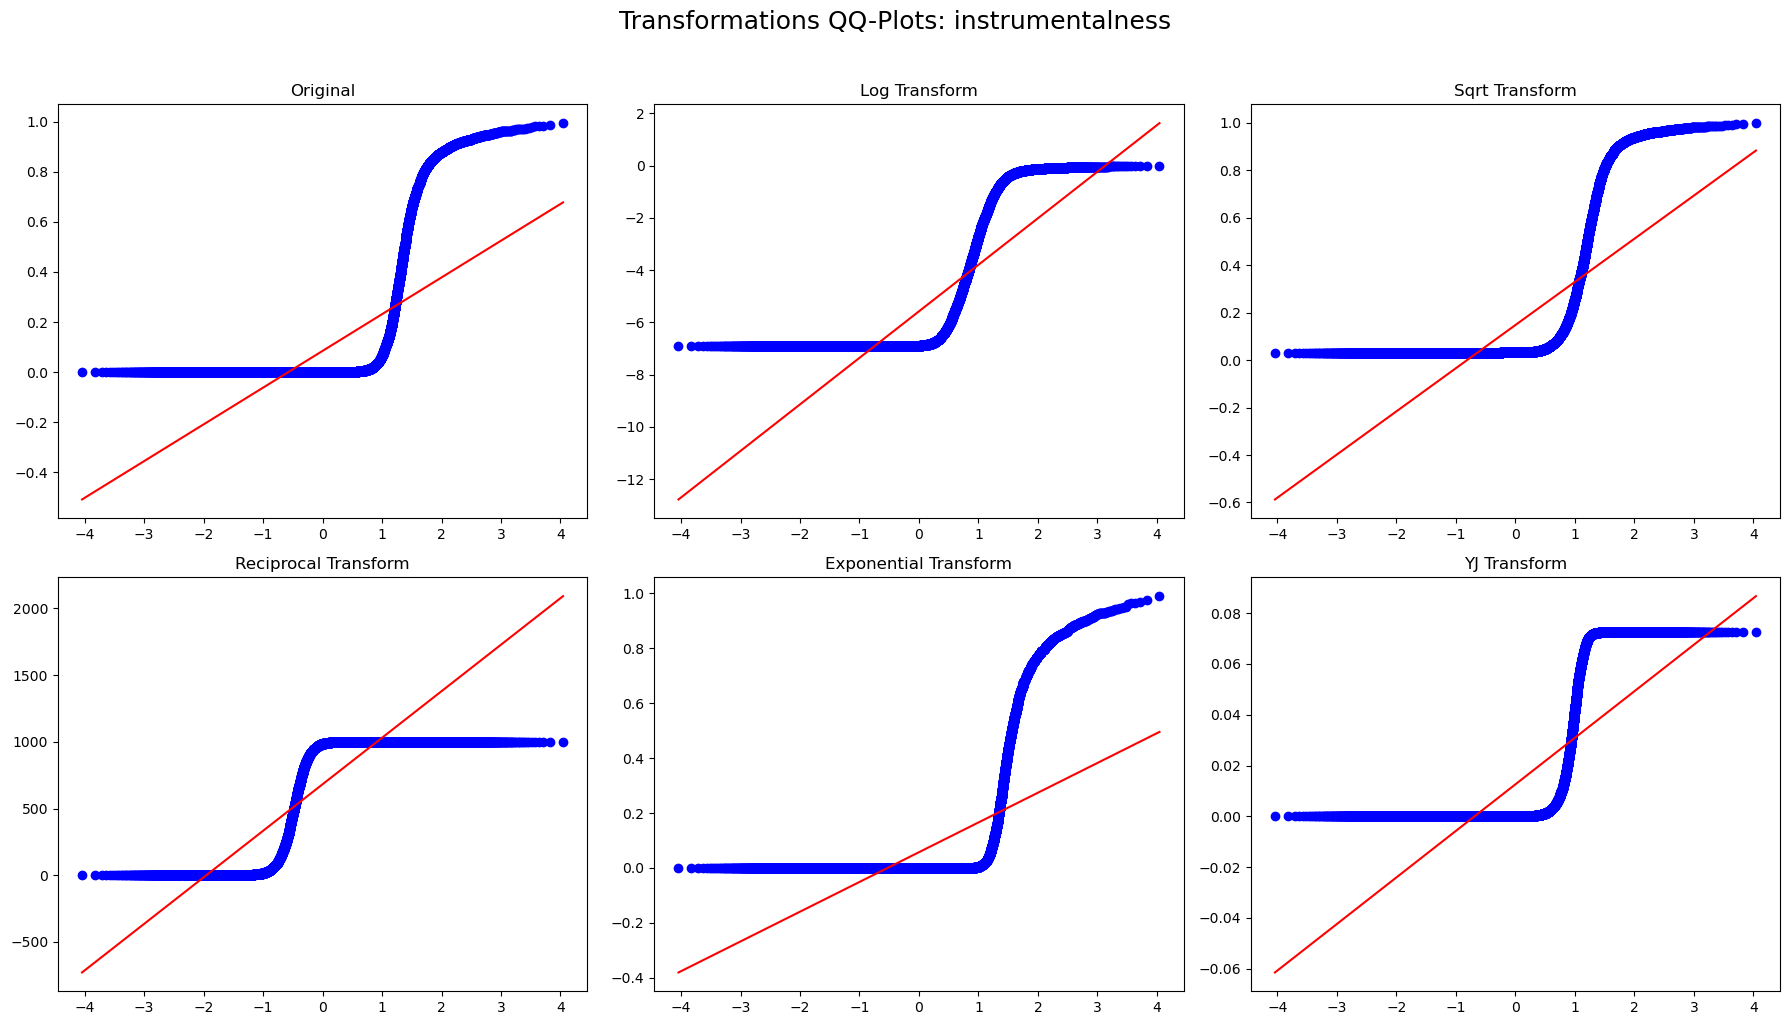

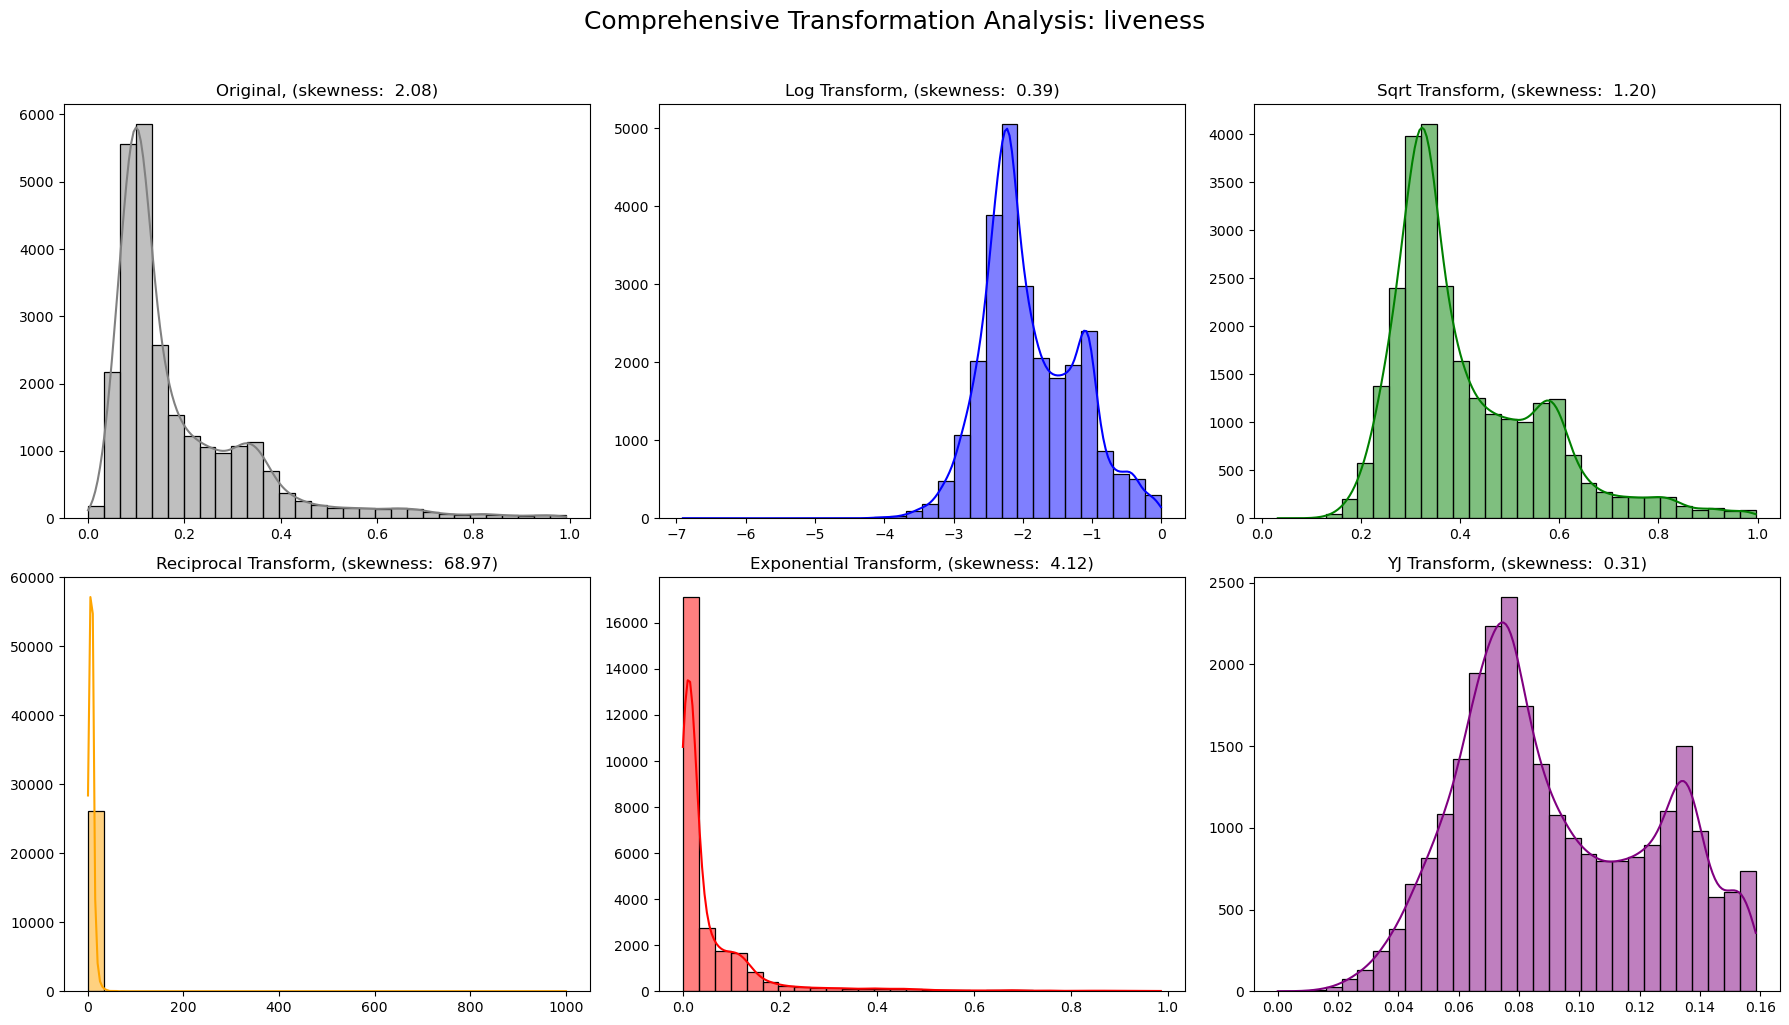

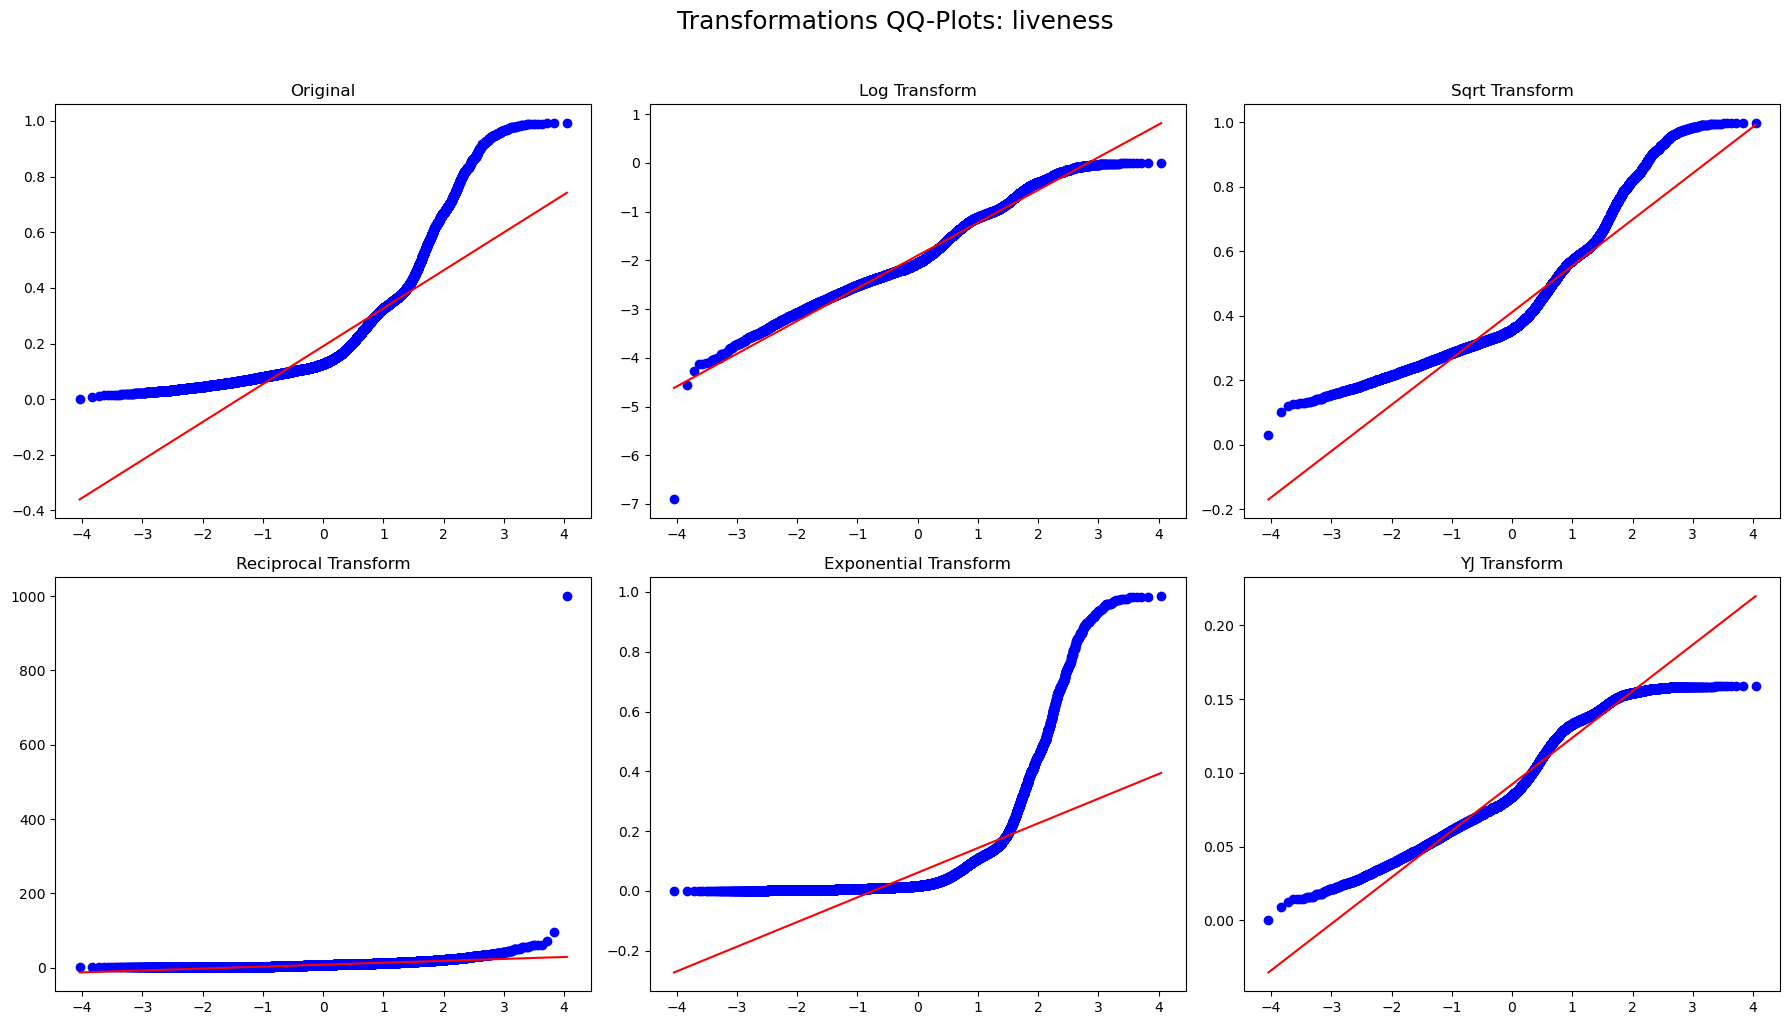

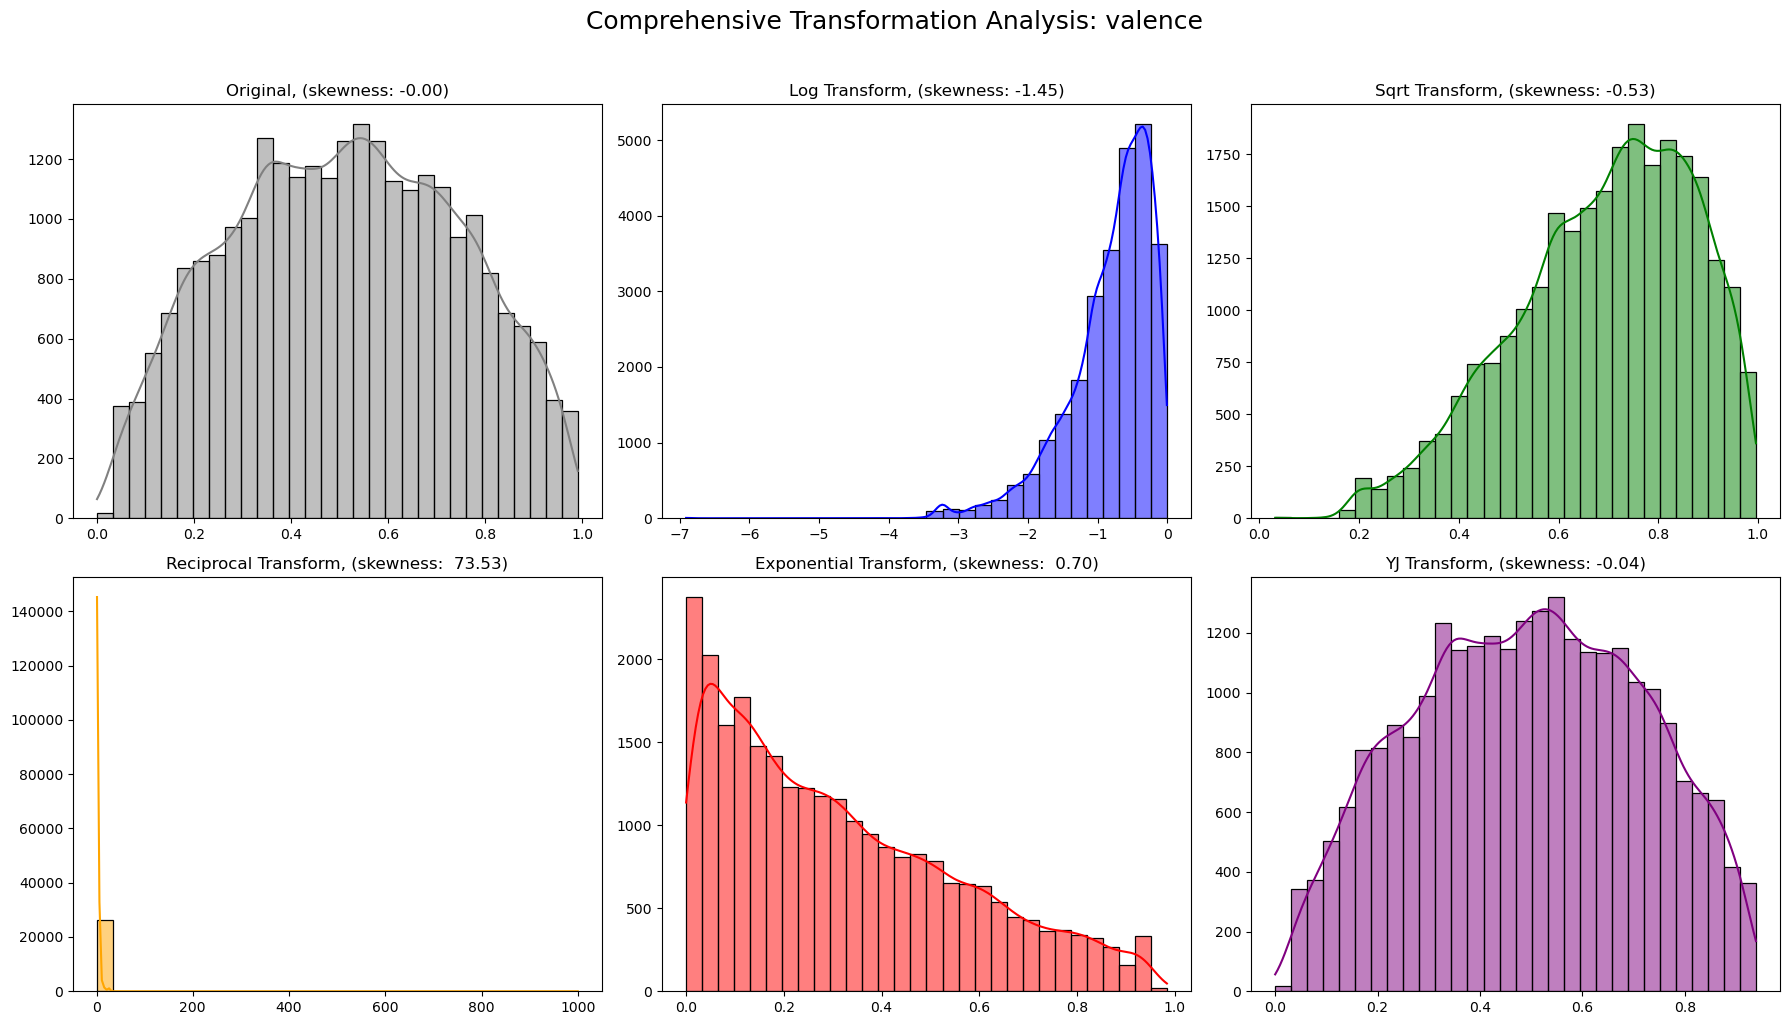

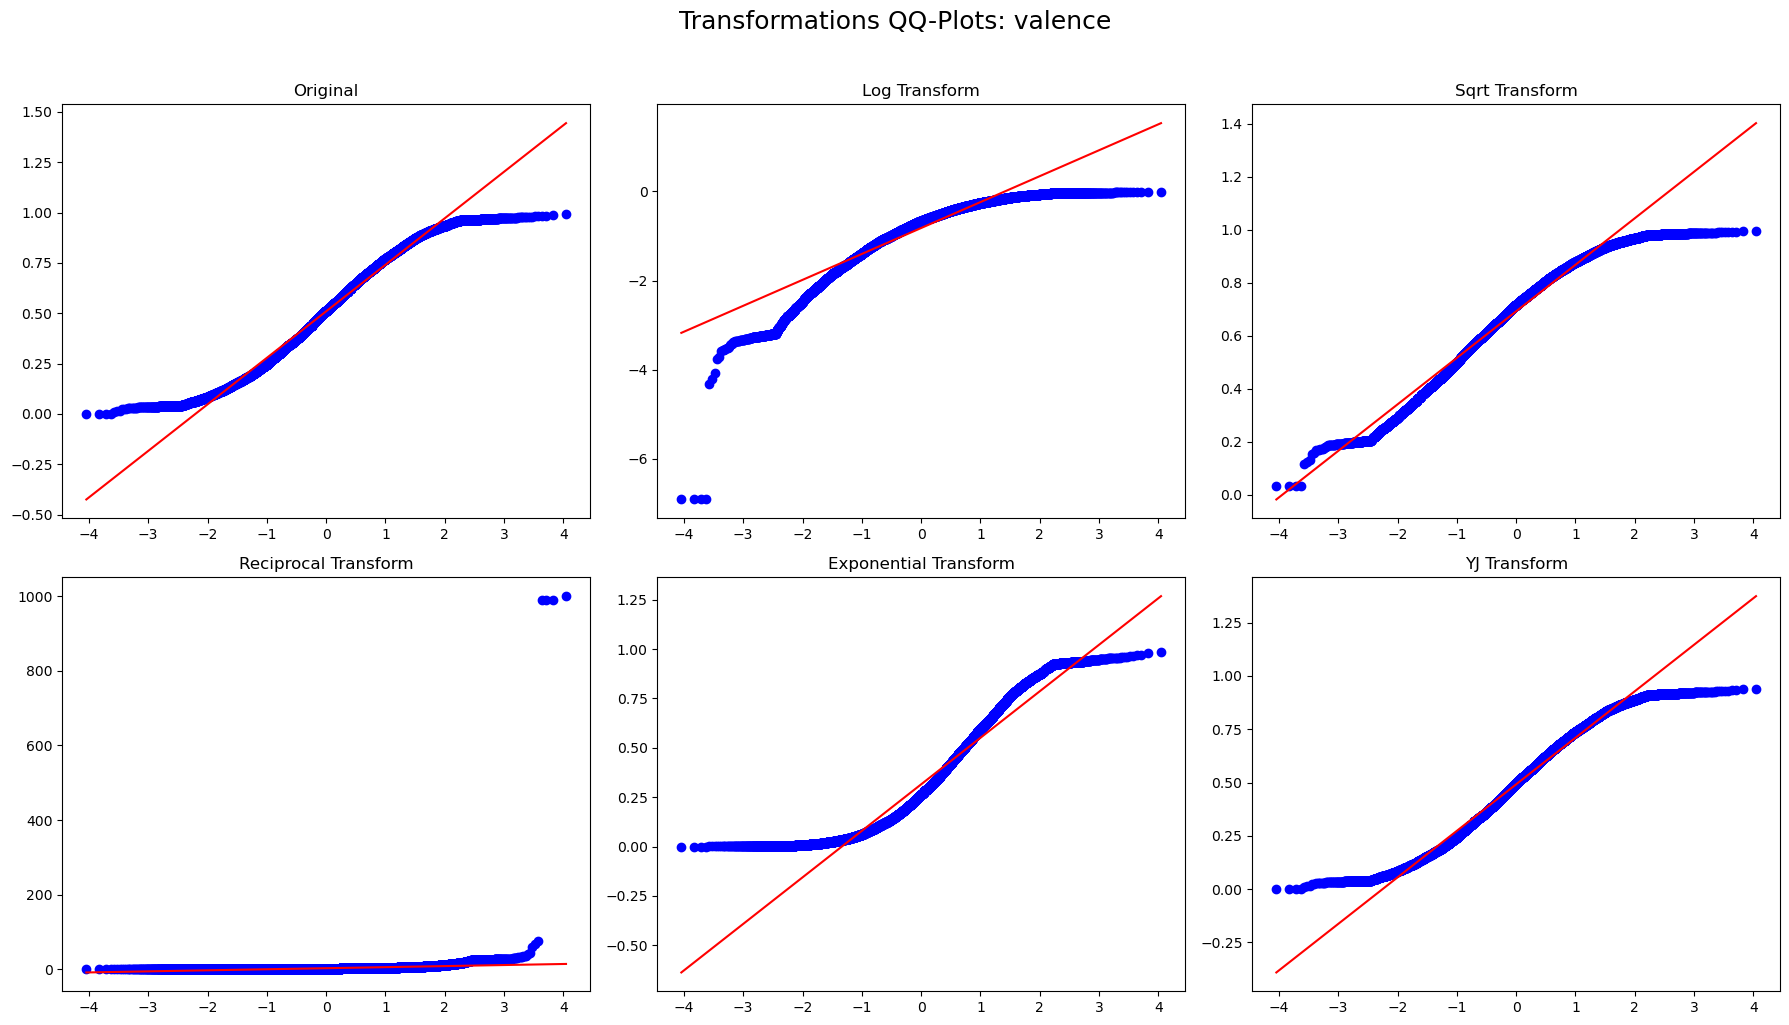

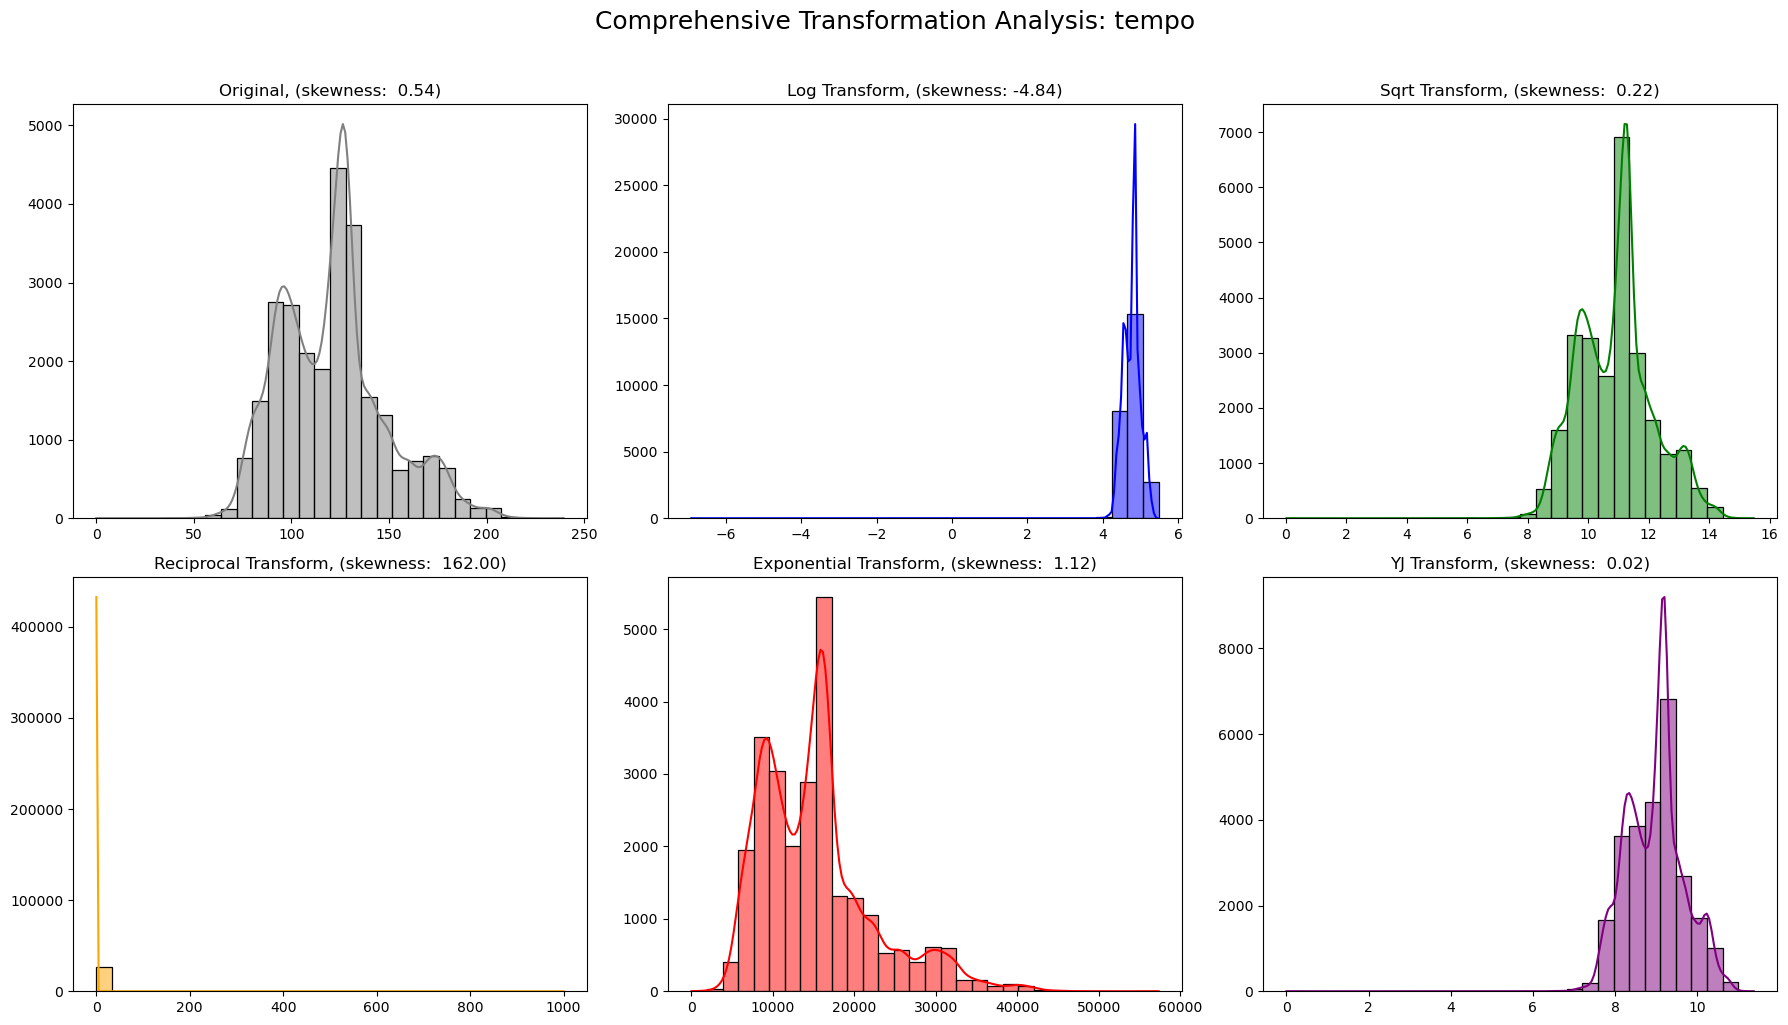

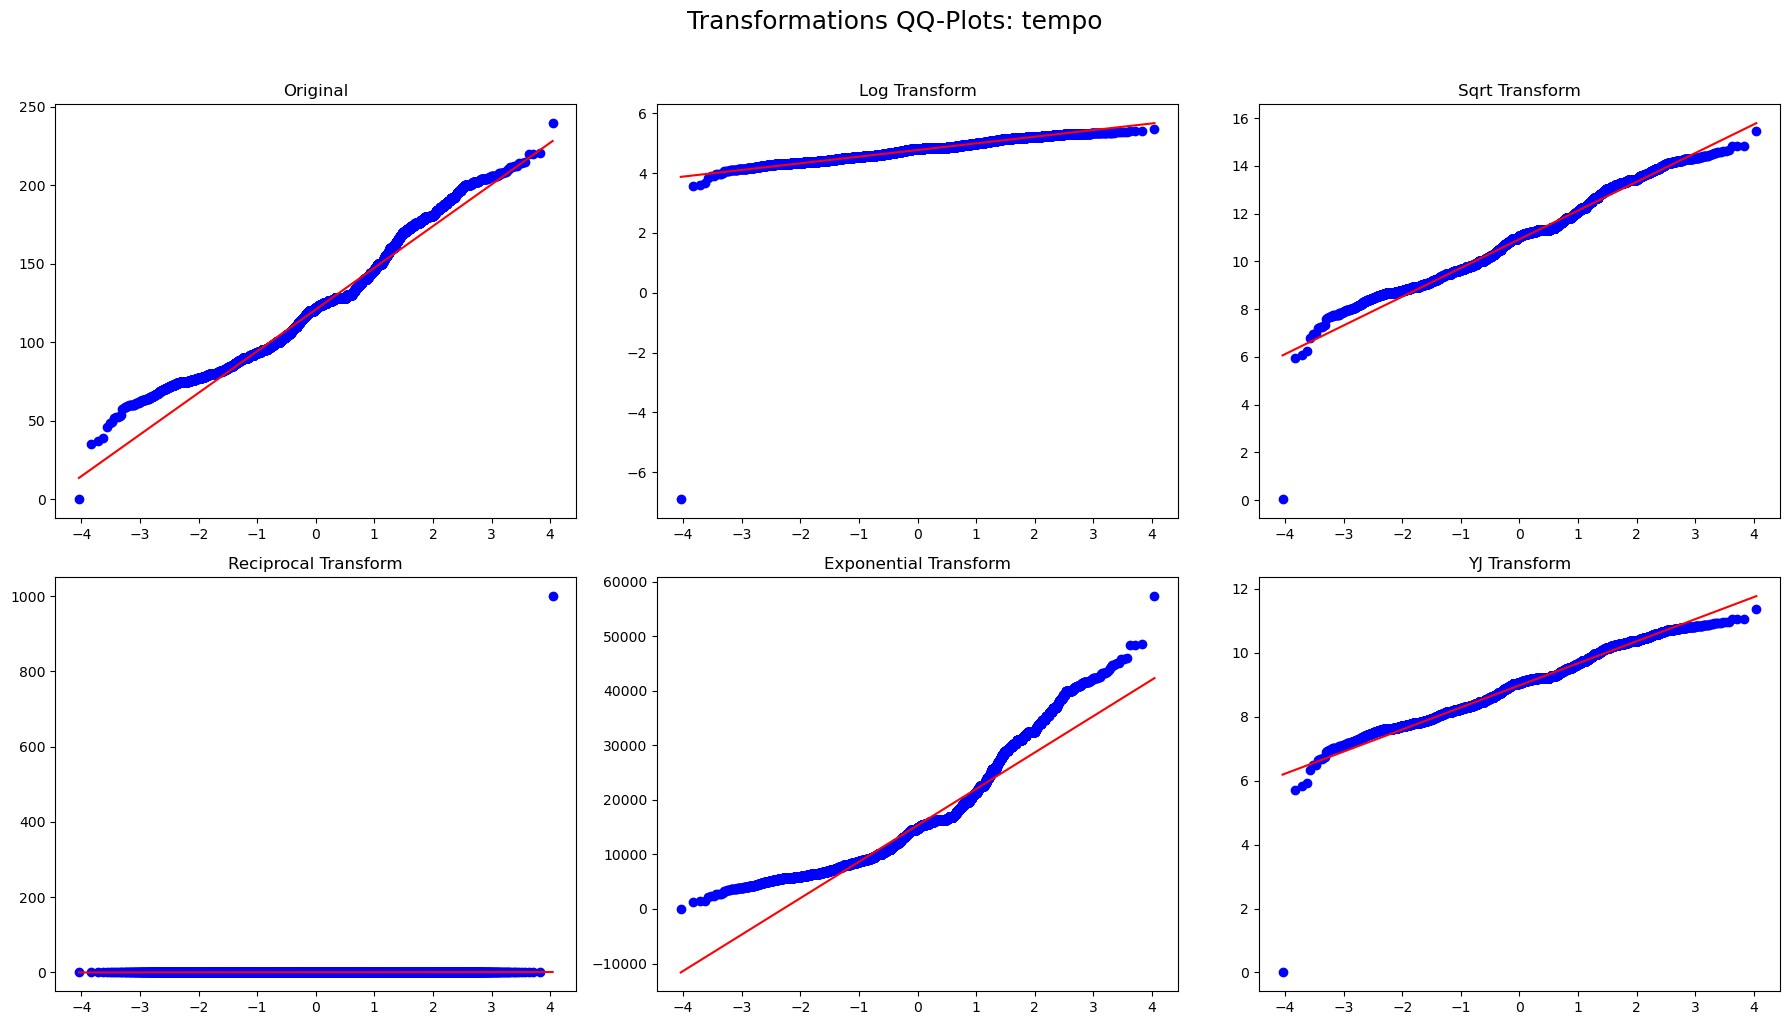

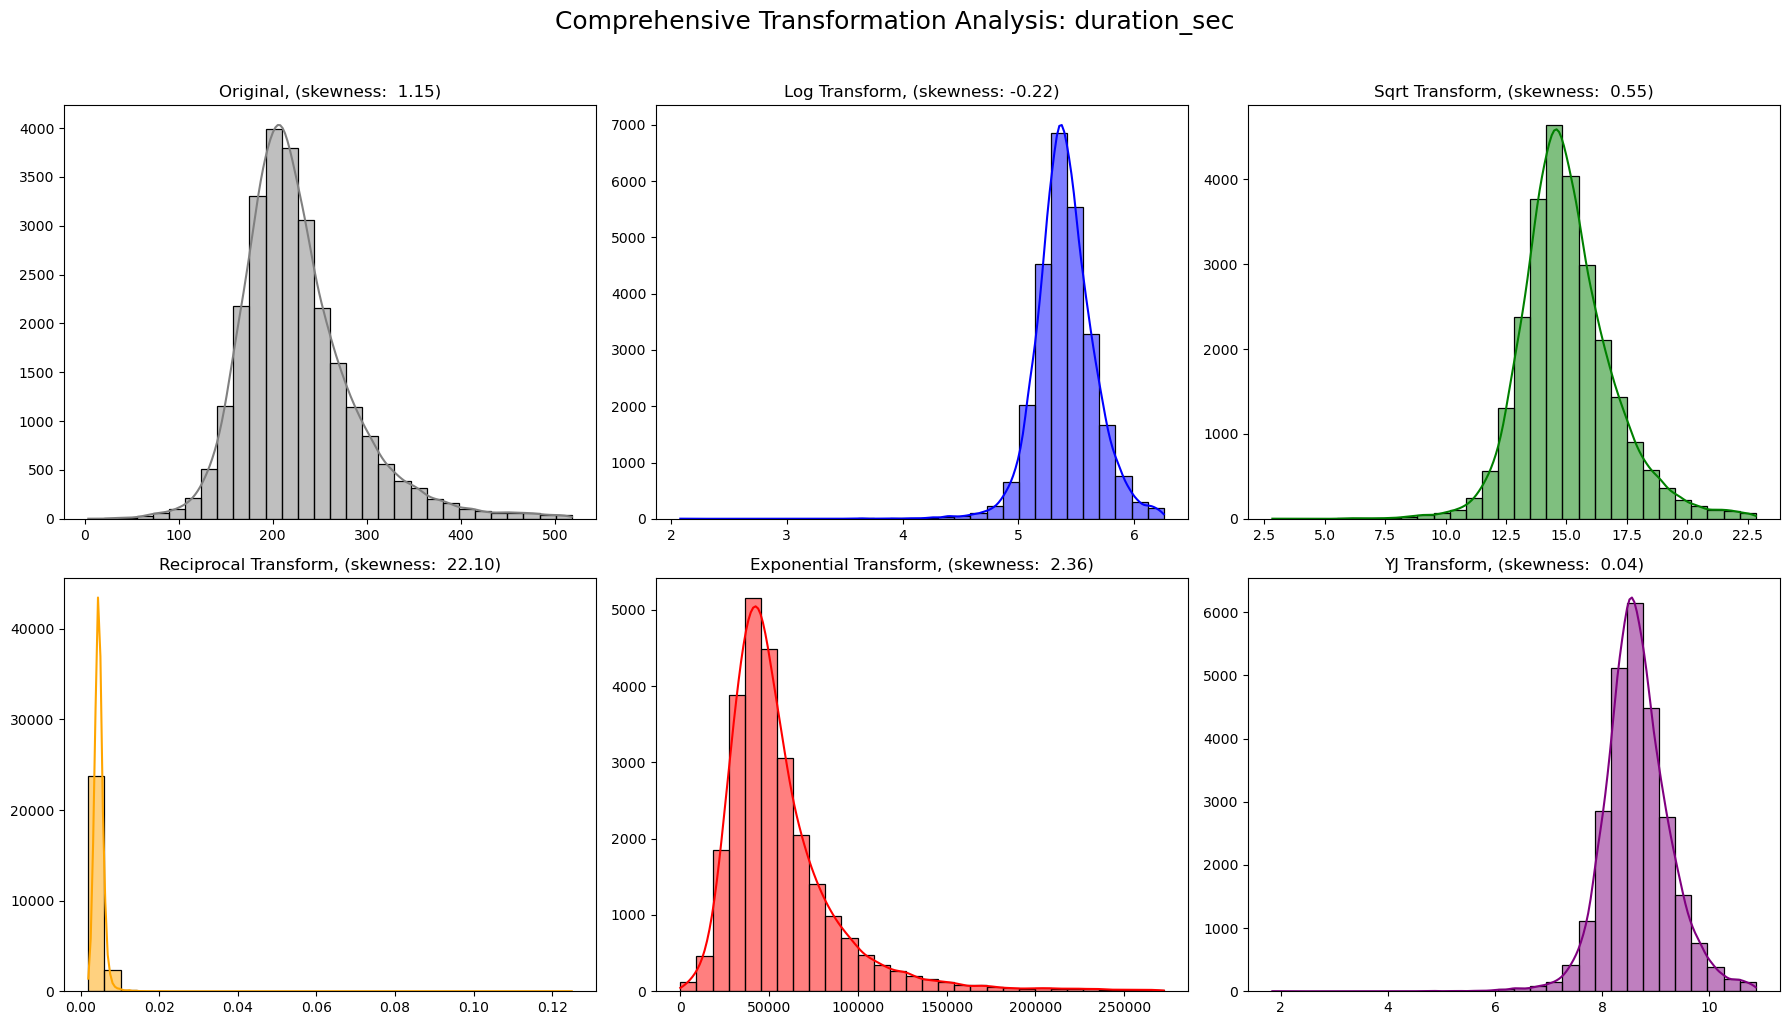

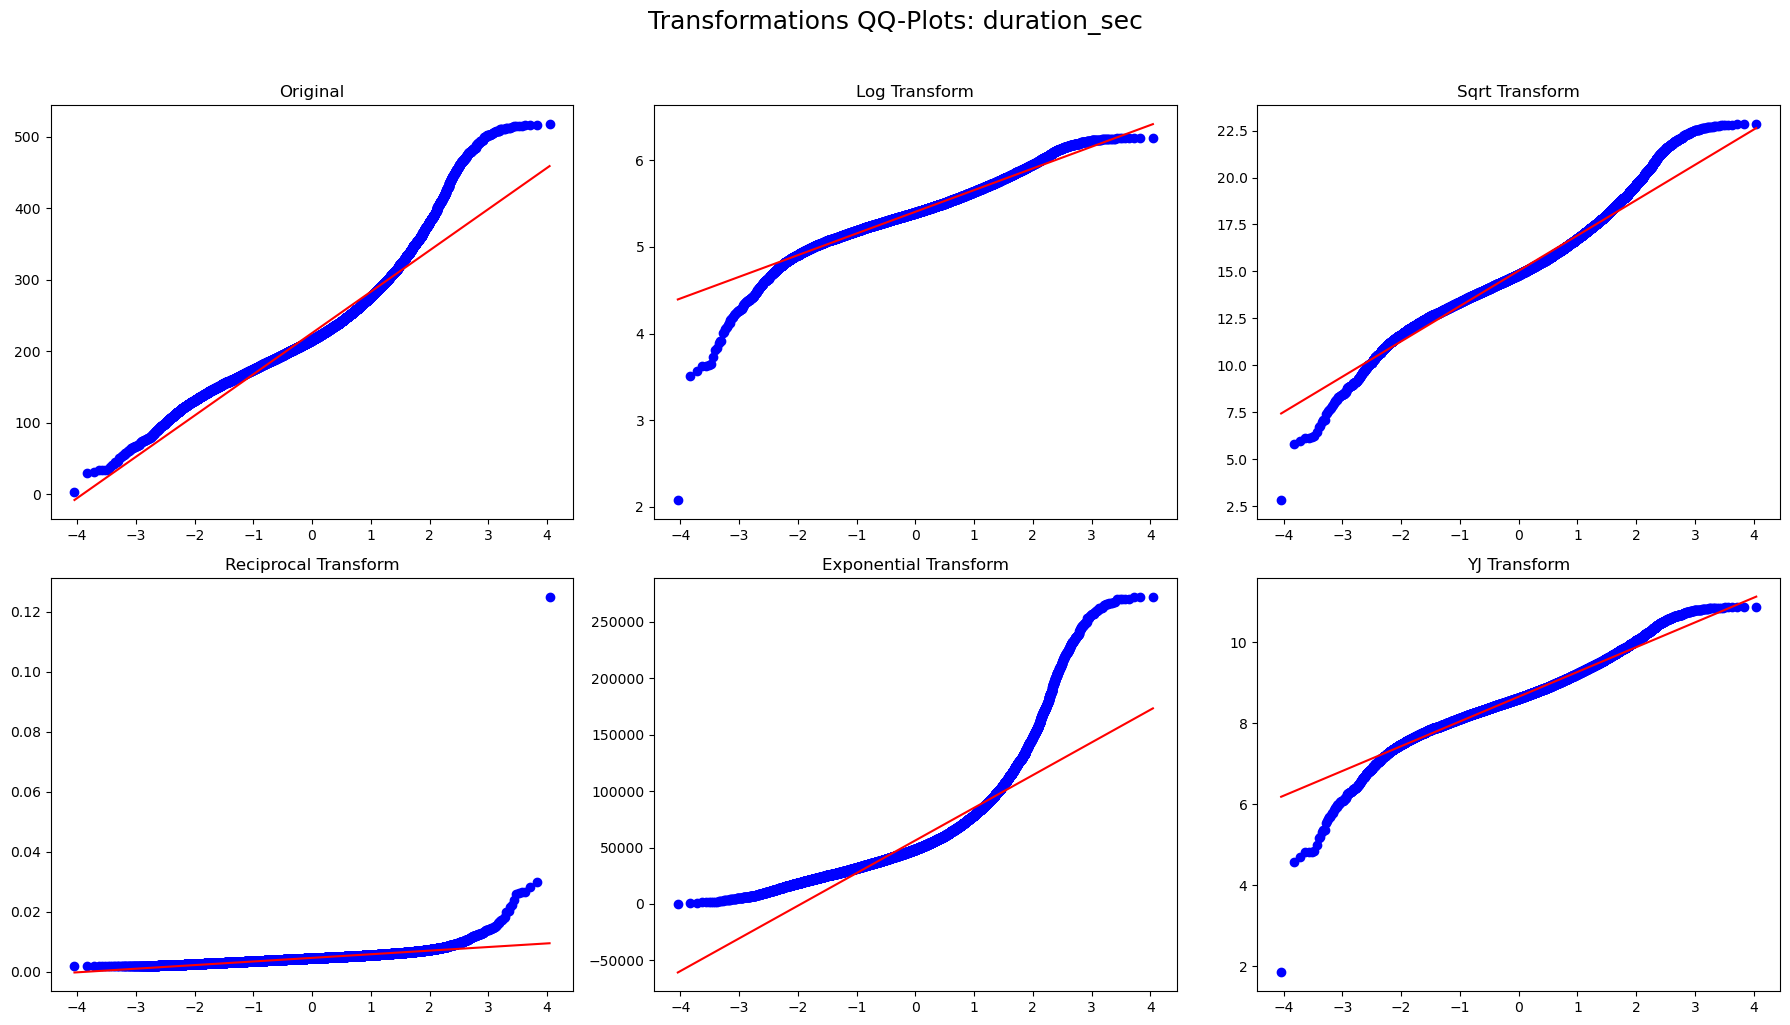

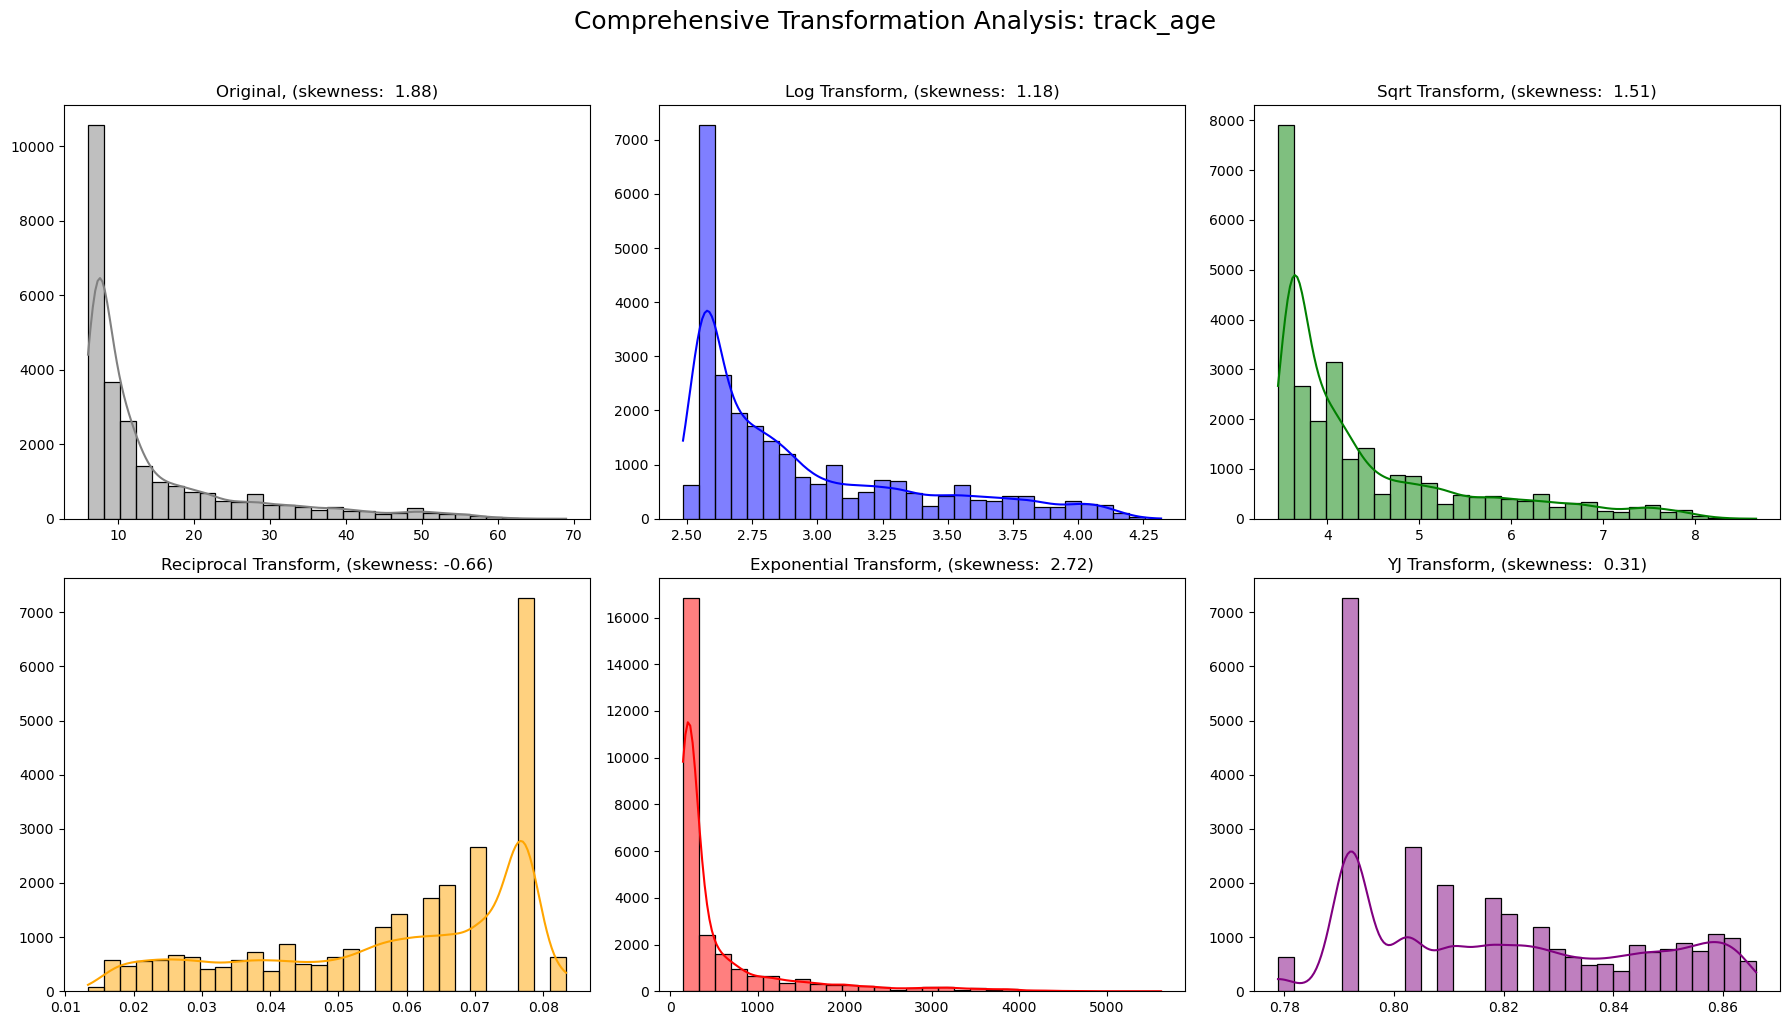

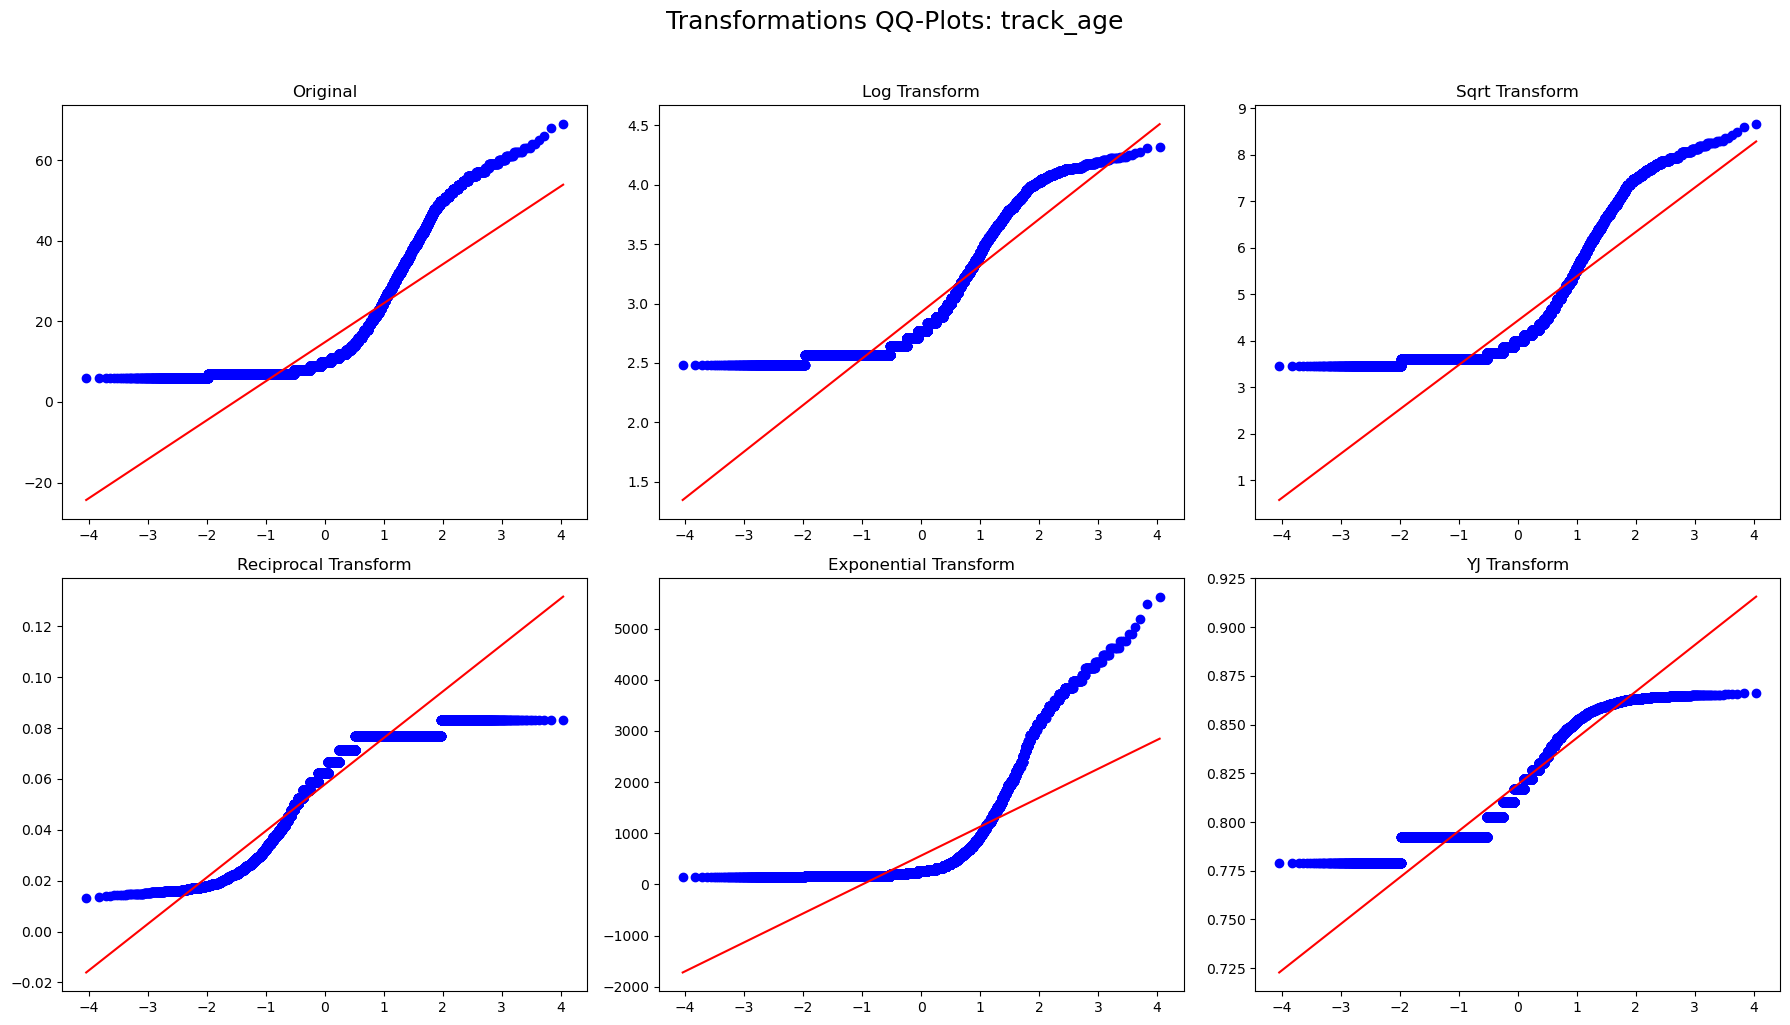

In [9]:
for i, feature in enumerate(continuous_features):
    plot_transformations(X_train, continuous_features[i])

# Feature Transformations (temporarily for outliers removal)

In [10]:
# Transformations Specifically For Removing Outliers (according to results):
    # original = ['valence', 'tempo', 'duration_sec'] 
    # yj_transform = ['danceability', 'loudness']
    # expo_transform = ['energy']
    # log_transform = ['speechiness', 'liveness', 'track_age']
    # sqrt_transform = ['acousticness']

In [11]:
def features_transformations(data):
    x = data.copy()

    transformations = {
        'yj_transform' : ['danceability', 'loudness'],
        'expo_transform' : ['energy'],
        'log_transform' :['speechiness', 'liveness', 'track_age'],
        'sqrt_transform' : ['acousticness']
    }

    def apply_shift(feature_data):
        min_val = feature_data.min()
        shift = (abs(min_val) + 0.001) if min_val <= 0 else 0
        return feature_data + shift
    
    def yj_transform(feature_name):
        return stats.yeojohnson(x[feature_name])[0] # [0] responsible for the data.

    def expo_transform(feature_name):
        return x[feature_name] ** 2

    def log_transform(feature_name):
        shifted_data = apply_shift(x[feature_name])
        return np.log(shifted_data)
    
    def sqrt_transform(feature_name):
        shifted_data = apply_shift(x[feature_name])
        return np.sqrt(shifted_data)

    for key, features_list in transformations.items():
        for feature in features_list:
            if key == 'yj_transform':
                x[feature] = yj_transform(feature)
            elif key == 'expo_transform':
                x[feature] = expo_transform(feature)
            elif key == 'log_transform':
                x[feature] = log_transform(feature)
            elif key == 'sqrt_transform':
                x[feature] = sqrt_transform(feature)
    
    return x

In [12]:
X_train_linear = features_transformations(X_train)

# Outliers Removal

In [13]:
# 'instrumentalness' is out of outliers removal because above 80% of his values are 0, so any other value will be considered as an outlier.
# Zscore: 'danceability','energy', 'loudness', 'valence', 'duration_sec'
# IQR: 'speechiness', 'acousticness', 'liveness', 'tempo', 'track_age'

In [14]:
outliers_df = X_train_linear.copy()
IQR_features = ['speechiness', 'acousticness', 'liveness', 'tempo', 'track_age']
Zscore_features = ['danceability','energy', 'loudness', 'valence', 'duration_sec']

def detect_IQR_outlier(data, features, factor = 1.5):
    x = data.copy()

    for feature in features:
        Q1 = x[feature].quantile(0.25)
        Q3 = x[feature].quantile(0.75)
        IQR_val = Q3 - Q1
        lower_bound = Q1 - (factor * IQR_val)
        upper_bound = Q3 + (factor * IQR_val)

        x[feature] = (x[feature] < lower_bound) | (x[feature] > upper_bound)
        
    return x

def detect_Zscore_outlier(data, features, threshold = 3.0):
    x = data.copy()
    
    for feature in features:
        mean = x[feature].mean()
        std = x[feature].std()
        zscores = (x[feature] - mean) / std
        
        x[feature] = abs(zscores) > threshold
    
    return x

outliers_df = detect_IQR_outlier(outliers_df, IQR_features, factor = 1.5)
outliers_df = detect_Zscore_outlier(outliers_df, Zscore_features, threshold = 3.0)

print(outliers_df[IQR_features + Zscore_features].sum())

speechiness      17
acousticness      0
liveness         22
tempo           473
track_age         0
danceability      1
energy            0
loudness        117
valence           0
duration_sec    420
dtype: int64


In [15]:
# removing outliers both from X_train (original, will serve the non-linear model) and from X_train_linear (after transformations):
def get_bad_rows_indices(outlier_mask_df, features_list, threshold = 0.2):
    
    total_outliers_per_row = outlier_mask_df[features_list].sum(axis = 1)
    min_outliers_to_drop = threshold * len(features_list)

    bad_indices = outlier_mask_df[total_outliers_per_row >= min_outliers_to_drop].index

    return bad_indices

all_outliers_features = IQR_features + Zscore_features
bad_rows = get_bad_rows_indices(outliers_df, all_outliers_features , threshold=0.2)
print(len(bad_rows))

12


In [16]:
X_train = X_train.drop(index = bad_rows)
X_train_linear = X_train_linear.drop(index = bad_rows)  